# MAT_SCI 465: Advanced Electron Microscopy & Diffraction## Week 03 & 04 Combined Assignment
**Classical, ML, and Deep Learning Approaches to Microscopy Analysis**
**Dataset:** DOPAD (416×416 cropped TEM images)
**Annotations:** 30 LabelMe pixel-level masks for Task 3**Source:** https://dopad.github.io/

## Objective
Compare classical computer vision, machine learning, and deep learning approaches on the same electron microscopy dataset. Progress from traditional image processing through supervised and unsupervised learning to modern deep learning, enabling direct quantitative comparison of all methods.

In [1]:
# ==============================================================
# Task 1 — Imports and Data Loading
# ==============================================================
from pathlib import Path
import numpy as np
import pandas as pd
from skimage import exposure, filters, measure, morphology, segmentation, color
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.morphology import disk
from skimage.feature import (peak_local_max, canny, local_binary_pattern,
                              blob_log)
from skimage.filters import sobel
from skimage.transform import resize as sk_resize
from scipy import ndimage
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 150,
                            'savefig.bbox': 'tight', 'savefig.dpi': 150})
import matplotlib.pyplot as plt
import os, time, glob, warnings, random
warnings.filterwarnings('ignore')

# ====== CHANGE THESE PATHS ======
IMAGE_DIR      = Path('./samples/samples')
LABELME_ROOT   = Path('./labelme_mask_30')
LABEL_CSV      = Path('./particle_labels.csv')   # generated by generate_particle_labels.py
# =================================

LABELME_IMG_DIR  = LABELME_ROOT / 'images'
LABELME_MASK_DIR = LABELME_ROOT / 'masks'

assert IMAGE_DIR.exists(), f"IMAGE_DIR not found: {IMAGE_DIR}"
print(f"IMAGE_DIR: {IMAGE_DIR}")

sample_images = sorted(list(IMAGE_DIR.glob('*.png')) +
                       list(IMAGE_DIR.glob('*.tif')) +
                       list(IMAGE_DIR.glob('*.jpg')))
print(f"Total images available: {len(sample_images)}")

NUM_IMAGES = min(100, len(sample_images))
ML_NUM     = min(50, NUM_IMAGES)

raw_image = imread(str(sample_images[0]))
if raw_image.ndim == 3:
    if raw_image.shape[-1] == 4: raw_image = raw_image[..., :3]
    raw_image = (rgb2gray(raw_image) * 255).astype(np.uint8)
print(f"Sample: {sample_images[0].name}, shape={raw_image.shape}")
print(f"Using {NUM_IMAGES} images for Task 1, {ML_NUM} for Task 2")

IMAGE_DIR: samples\samples
Total images available: 279054
Sample: 11500X00.png, shape=(416, 416)
Using 100 images for Task 1, 50 for Task 2


In [2]:
# ==============================================================
# Task 1 — Helper functions
# ==============================================================
def compute_snr(image):
    """Signal-to-noise ratio: SNR = mu / sigma."""
    s = np.std(image)
    return float(np.mean(image) / s) if s > 0 else np.inf

def load_gray(path):
    """Load an image and convert to float64 grayscale in [0, 1]."""
    img = imread(str(path))
    if img.ndim == 3:
        if img.shape[-1] == 4: img = img[..., :3]
        if img.shape[-1] == 1: img = img[..., 0].astype(np.float64)
        else: img = rgb2gray(img)
    else:
        img = img.astype(np.float64)
    if img.max() > 1:
        img = img / 255.0 if img.max() <= 255 else img / img.max()
    return img

def classical_pipeline(image):
    """Full classical pipeline: median → CLAHE → Otsu → Watershed."""
    filtered  = filters.median(image, disk(3))
    enhanced  = exposure.equalize_adapthist(filtered, clip_limit=0.025)
    thr       = filters.threshold_otsu(enhanced)
    binary    = enhanced < thr
    if binary.sum() > binary.size * 0.5:
        binary = ~binary
    binary = morphology.remove_small_objects(binary, min_size=50)
    binary = morphology.binary_closing(binary, disk(2))
    binary = ndimage.binary_fill_holes(binary)
    dist   = ndimage.distance_transform_edt(binary)
    coords = peak_local_max(dist, min_distance=10, labels=binary)
    mk     = np.zeros(dist.shape, dtype=bool)
    if len(coords) > 0:
        mk[tuple(coords.T)] = True
    markers = ndimage.label(mk)[0]
    labels  = segmentation.watershed(-dist, markers, mask=binary)
    props   = measure.regionprops(labels, intensity_image=enhanced)
    rows = []
    for p in props:
        pe = max(p.perimeter, 1e-10)
        rows.append(dict(
            label=p.label, area=p.area,
            equivalent_diameter=p.equivalent_diameter,
            eccentricity=p.eccentricity, solidity=p.solidity,
            perimeter=pe, circularity=4*np.pi*p.area/pe**2,
            mean_intensity=p.mean_intensity,
            max_intensity=p.max_intensity, min_intensity=p.min_intensity))
    return filtered, enhanced, labels, pd.DataFrame(rows)

In [3]:
# ==============================================================
# Task 1 — Process images
# ==============================================================
print(f"Processing {NUM_IMAGES} images ...")
all_meas, snr_bef, snr_aft = [], [], []
t0 = time.time()
for i in range(NUM_IMAGES):
    img = load_gray(sample_images[i])
    snr_bef.append(compute_snr(img))
    filt, enh, labs, meas = classical_pipeline(img)
    snr_aft.append(compute_snr(filt))
    meas['image_index'] = i
    meas['image_name']  = sample_images[i].name
    all_meas.append(meas)
    if (i+1) % 25 == 0:
        print(f"  {i+1}/{NUM_IMAGES}")

classical_runtime = time.time() - t0
classical_df = pd.concat(all_meas, ignore_index=True)
classical_df.to_csv('classical_results.csv', index=False)
classical_particle_count = len(classical_df)
print(f"Done in {classical_runtime:.1f}s ({classical_runtime/NUM_IMAGES:.2f}s/img)")
print(f"Particles detected: {classical_particle_count}")
print(f"SNR: {np.mean(snr_bef):.2f} → {np.mean(snr_aft):.2f}")

Processing 100 images ...
  25/100
  50/100
  75/100
  100/100
Done in 31.6s (0.32s/img)
Particles detected: 9247
SNR: 5.74 → 6.28


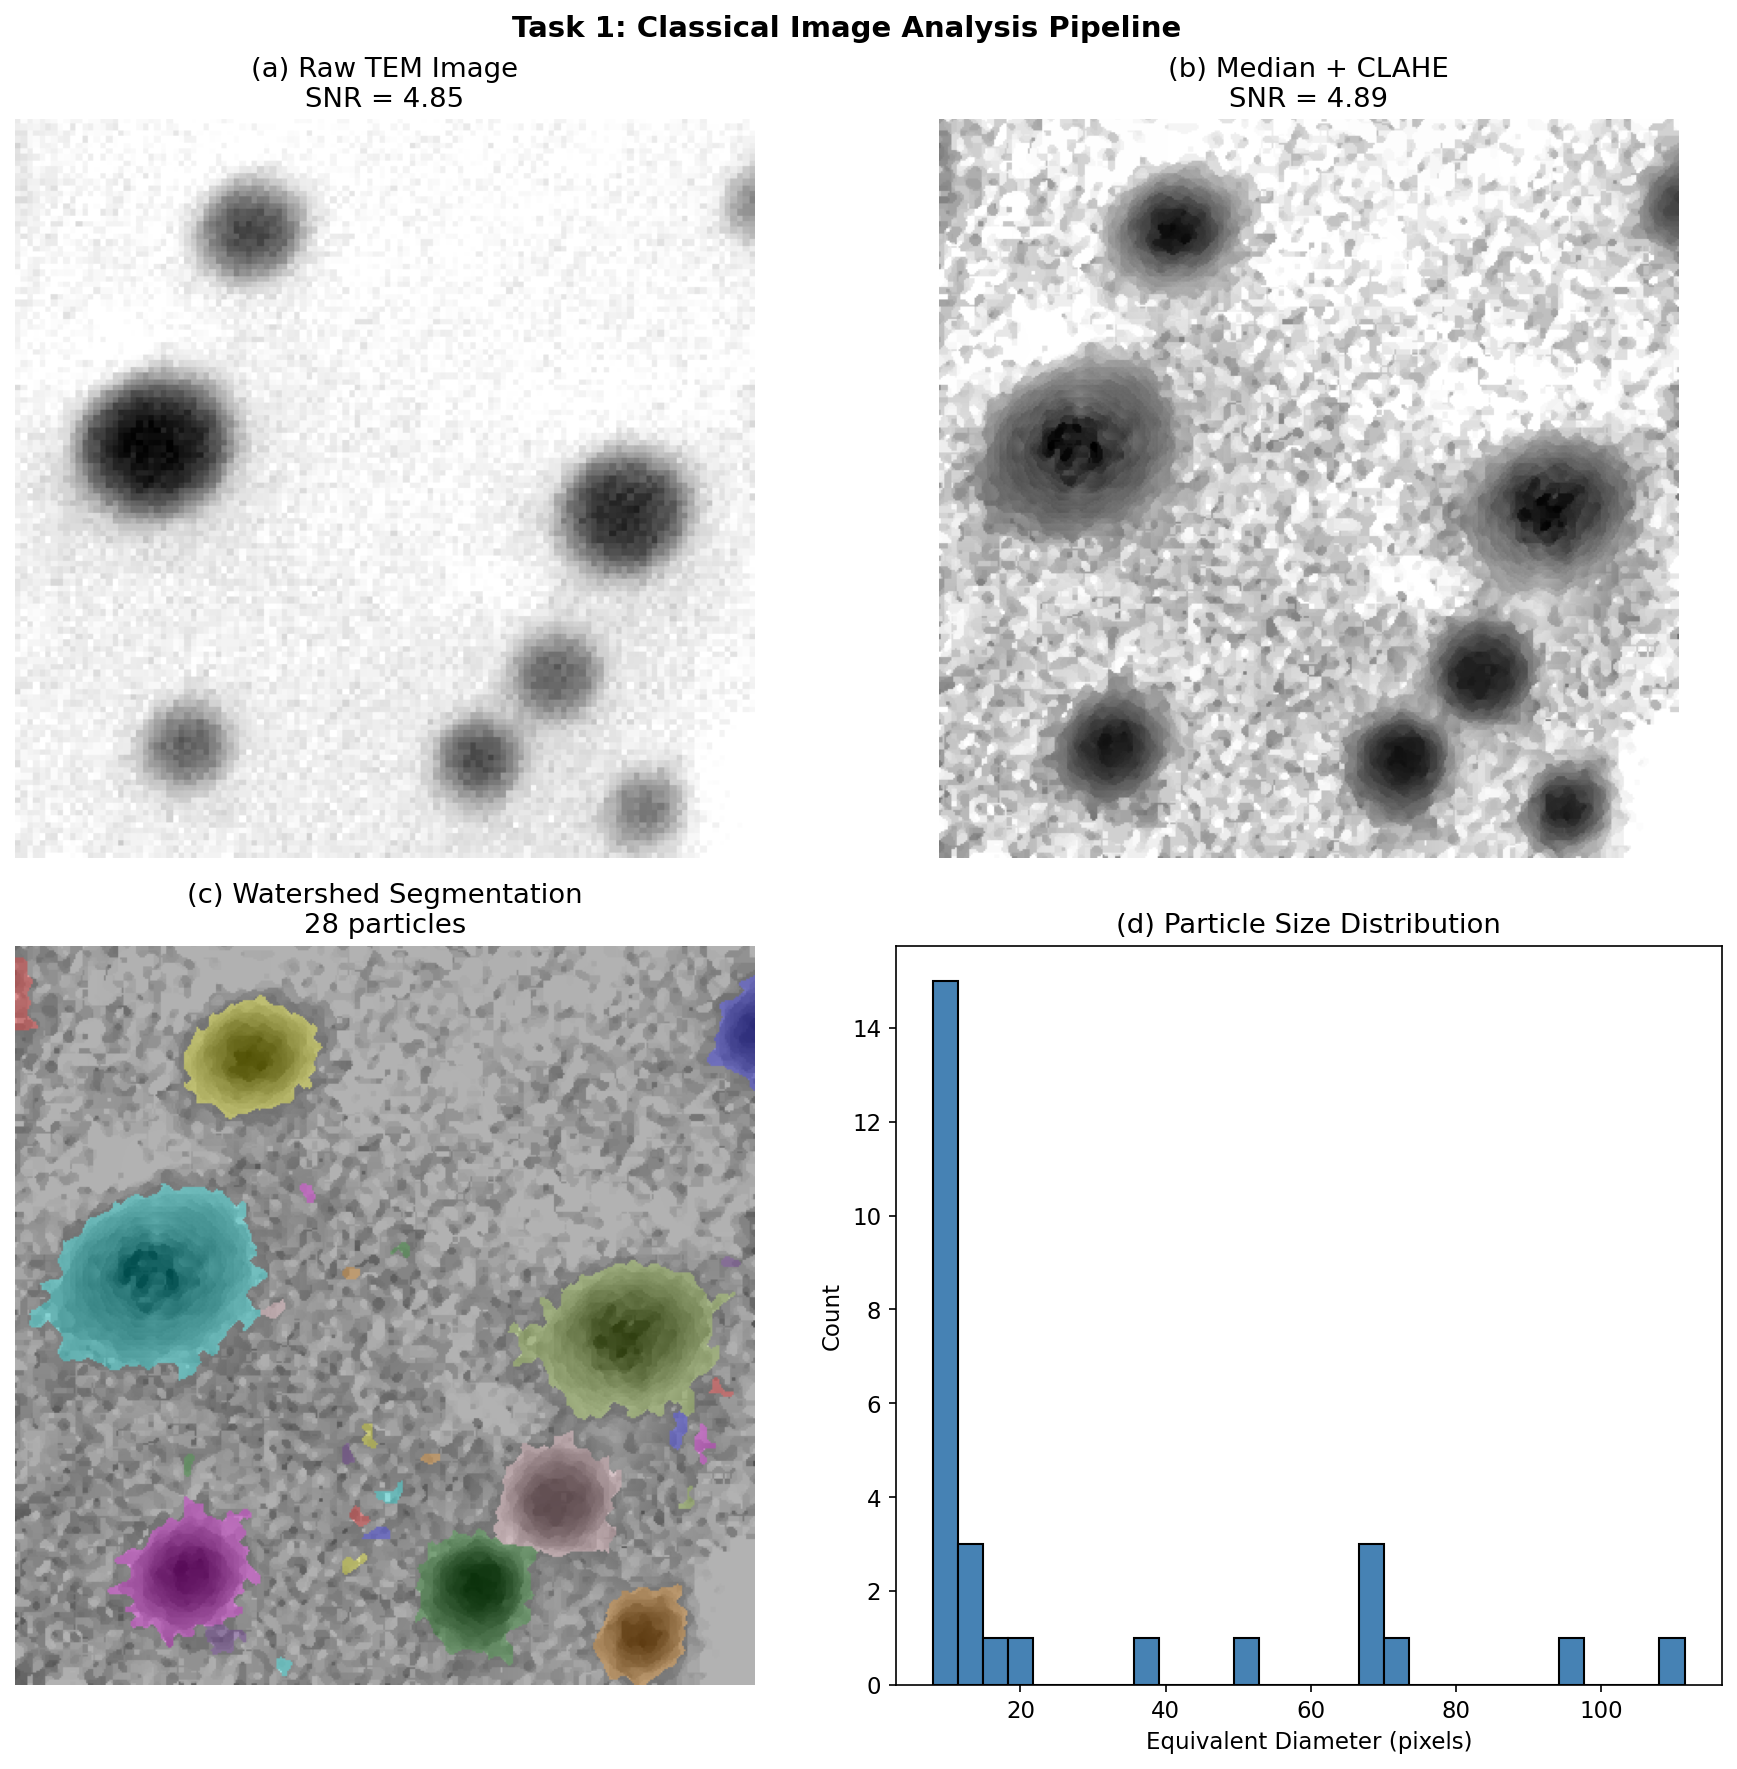

In [4]:
# ==============================================================
# Task 1 — Four-panel figure
# ==============================================================
img0 = load_gray(sample_images[0])
f0, e0, l0, m0 = classical_pipeline(img0)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes[0,0].imshow(img0, cmap='gray')
axes[0,0].set_title(f'(a) Raw TEM Image\nSNR = {compute_snr(img0):.2f}')
axes[0,0].axis('off')

axes[0,1].imshow(e0, cmap='gray')
axes[0,1].set_title(f'(b) Median + CLAHE\nSNR = {compute_snr(f0):.2f}')
axes[0,1].axis('off')

axes[1,0].imshow(color.label2rgb(l0, image=e0, bg_label=0))
axes[1,0].set_title(f'(c) Watershed Segmentation\n{l0.max()} particles')
axes[1,0].axis('off')

if len(m0) > 0:
    axes[1,1].hist(m0['equivalent_diameter'], bins=30, color='steelblue', edgecolor='black')
    axes[1,1].set_xlabel('Equivalent Diameter (pixels)')
    axes[1,1].set_ylabel('Count')
    axes[1,1].set_title('(d) Particle Size Distribution')

plt.suptitle('Task 1: Classical Image Analysis Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task1_four_panel.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ==============================================================
# Task 2 — Feature extraction (16 descriptors / region)
# Includes: morphology, edges (Canny/Sobel), blobs (LoG), textures (LBP)
# ==============================================================
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import (classification_report, confusion_matrix,
    silhouette_score, f1_score, precision_score, recall_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import seaborn as sns

def extract_features(image, labels):
    """Extract 16 features per region: morphology + edge + LoG blob + LBP texture."""
    enh  = exposure.equalize_adapthist(image, clip_limit=0.025)
    edge = canny(enh, sigma=1.5).astype(float)
    sob  = sobel(enh)
    lbp  = local_binary_pattern((enh*255).astype(np.uint8), P=8, R=1, method='uniform')

    # LoG blob detection on the whole image
    blobs = blob_log(enh, min_sigma=2, max_sigma=15, num_sigma=5, threshold=0.05)
    # blobs[:,0]=y, blobs[:,1]=x, blobs[:,2]=sigma
    blob_map = np.zeros(enh.shape, dtype=float)
    for b in blobs:
        rr, cc = int(b[0]), int(b[1])
        if 0 <= rr < enh.shape[0] and 0 <= cc < enh.shape[1]:
            blob_map[rr, cc] = b[2]  # sigma as blob strength

    props = measure.regionprops(labels, intensity_image=enh)
    rows = []
    for p in props:
        if p.area < 20:
            continue
        r0, c0, r1, c1 = p.bbox
        pe = max(p.perimeter, 1e-10)
        m  = labels[r0:r1, c0:c1] == p.label
        ri = enh[r0:r1, c0:c1][m]

        # LoG blob features for this region
        region_blobs   = blob_map[r0:r1, c0:c1][m]
        blob_count     = np.sum(region_blobs > 0)
        blob_mean_sig  = np.mean(region_blobs[region_blobs > 0]) if blob_count > 0 else 0

        rows.append(dict(
            # Morphology (7)
            area=p.area, perimeter=pe,
            equivalent_diameter=p.equivalent_diameter,
            eccentricity=p.eccentricity, solidity=p.solidity,
            circularity=4*np.pi*p.area/pe**2,
            extent=p.extent,
            # Intensity (2)
            mean_intensity=p.mean_intensity,
            std_intensity=np.std(ri) if len(ri) > 1 else 0,
            # Edge features (3)
            edge_ratio=np.sum(edge[r0:r1, c0:c1][m]) / p.area,
            sobel_mean=np.mean(sob[r0:r1, c0:c1][m]),
            sobel_std=np.std(sob[r0:r1, c0:c1][m]) if len(ri) > 1 else 0,
            # Blob / LoG features (2)
            blob_count=blob_count,
            blob_mean_sigma=blob_mean_sig,
            # Texture / LBP features (2)
            lbp_mean=np.mean(lbp[r0:r1, c0:c1][m]),
            lbp_std=np.std(lbp[r0:r1, c0:c1][m]) if len(ri) > 1 else 0,
        ))
    return pd.DataFrame(rows)

print(f"Extracting 16 features from {ML_NUM} images ...")
feat_list = []
for i in range(ML_NUM):
    img = load_gray(sample_images[i])
    _, _, labs, _ = classical_pipeline(img)
    df = extract_features(img, labs)
    df['image_index'] = i
    feat_list.append(df)
    if (i+1) % 25 == 0:
        print(f"  {i+1}/{ML_NUM}")

feature_df = pd.concat(feat_list, ignore_index=True)
print(f"Total: {len(feature_df)} regions, {len(feature_df.columns)-1} features each")

Extracting 16 features from 50 images ...
  25/50
  50/50
Total: 4314 regions, 16 features each


Loaded 4314 labels from particle_labels.csv
Matched 4292 regions with labels
Balanced dataset: 200 per class, 400 total
  Class 0 (small/round): 200
  Class 1 (large/elongated): 200

Feature Importance (top 10):
            feature  importance
       eccentricity    0.393348
          perimeter    0.070949
             extent    0.062162
equivalent_diameter    0.055721
        circularity    0.053630
               area    0.048573
         edge_ratio    0.040033
           lbp_mean    0.039732
         sobel_mean    0.037535
      std_intensity    0.035566

Selected top 7: ['edge_ratio', 'area', 'circularity', 'equivalent_diameter', 'extent', 'perimeter', 'eccentricity']


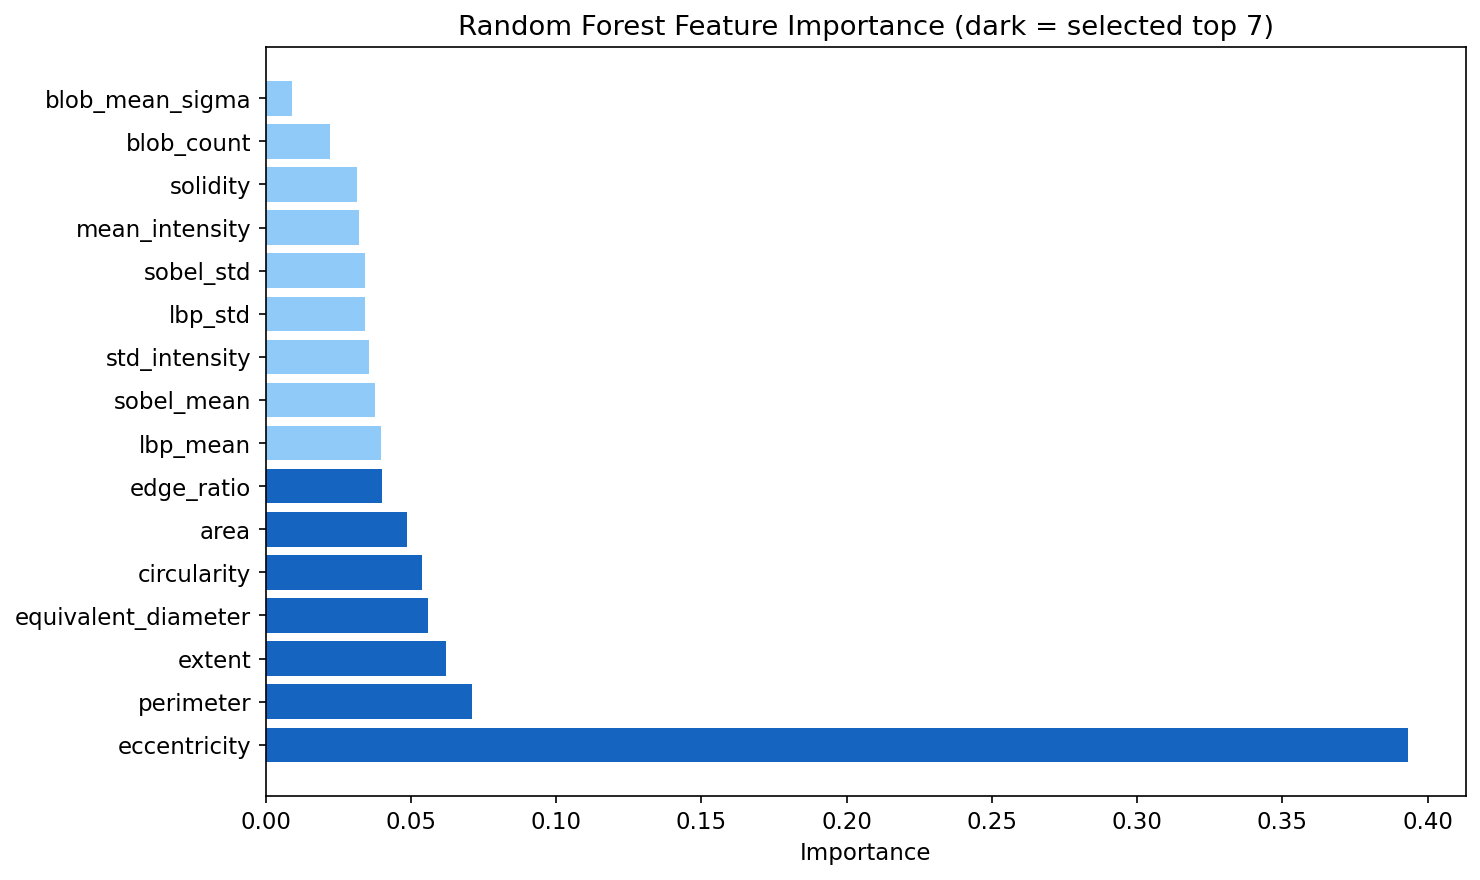

In [6]:
# ==============================================================
# Task 2 — Load pre-generated labels + feature selection
# ==============================================================
feat_cols = [
    'area', 'perimeter', 'equivalent_diameter', 'eccentricity',
    'solidity', 'circularity', 'extent',
    'mean_intensity', 'std_intensity',
    'edge_ratio', 'sobel_mean', 'sobel_std',
    'blob_count', 'blob_mean_sigma',
    'lbp_mean', 'lbp_std'
]

X_all    = feature_df[feat_cols].fillna(0).values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# --- Load pre-generated labels from particle_labels.csv ---
assert LABEL_CSV.exists(), (
    f"Label file not found: {LABEL_CSV}\n"
    "Run: python generate_particle_labels.py --image_dir ./samples/samples --n 50"
)
label_df = pd.read_csv(LABEL_CSV)
print(f"Loaded {len(label_df)} labels from {LABEL_CSV}")

# Merge labels with feature_df on (image_index, label_id)
# We need to re-extract label_id for feature_df rows.
# Since both use the same pipeline, the ordering is consistent.
# Match by image_index; label_id mapping via position within image.
feature_df_with_labels = feature_df.copy()
# Rebuild label_id per image group
feature_df_with_labels['label_id'] = feature_df_with_labels.groupby('image_index').cumcount() + 1

merged = feature_df_with_labels.merge(
    label_df[['image_index', 'label_id', 'class']],
    on=['image_index', 'label_id'], how='inner')
print(f"Matched {len(merged)} regions with labels")

labels_all = merged['class'].values
X_labeled  = scaler.transform(merged[feat_cols].fillna(0).values)

# Balanced subsample: 200 per class max
idx_c0 = np.where(labels_all == 0)[0]
idx_c1 = np.where(labels_all == 1)[0]
n_per_class = min(len(idx_c0), len(idx_c1), 200)
np.random.seed(42)
sel_c0 = np.random.choice(idx_c0, n_per_class, replace=False)
sel_c1 = np.random.choice(idx_c1, n_per_class, replace=False)
sel_idx = np.sort(np.concatenate([sel_c0, sel_c1]))

X_balanced         = X_labeled[sel_idx]
labels_supervised  = labels_all[sel_idx]
print(f"Balanced dataset: {n_per_class} per class, {len(sel_idx)} total")
print(f"  Class 0 (small/round): {(labels_supervised==0).sum()}")
print(f"  Class 1 (large/elongated): {(labels_supervised==1).sum()}")

# --- Feature importance ---
rf_imp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_imp.fit(X_balanced, labels_supervised)
importances = rf_imp.feature_importances_
importance_df = pd.DataFrame(
    {'feature': feat_cols, 'importance': importances}
).sort_values('importance', ascending=False)
print("\nFeature Importance (top 10):")
print(importance_df.head(10).to_string(index=False))

top_idx   = np.argsort(importances)[-7:]
top_names = [feat_cols[i] for i in top_idx]
X_selected = X_balanced[:, top_idx]
print(f"\nSelected top 7: {top_names}")

fig, ax = plt.subplots(figsize=(10, 6))
clrs = ['#1565C0' if f in top_names else '#90CAF9' for f in importance_df['feature']]
ax.barh(importance_df['feature'], importance_df['importance'], color=clrs)
ax.set_xlabel('Importance')
ax.set_title('Random Forest Feature Importance (dark = selected top 7)')
plt.tight_layout()
plt.savefig('task2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

=== SVM ===
                 precision    recall  f1-score   support

    Small/Round       0.90      0.70      0.79        40
Large/Elongated       0.76      0.93      0.83        40

       accuracy                           0.81        80
      macro avg       0.83      0.81      0.81        80
   weighted avg       0.83      0.81      0.81        80

=== Random Forest ===
                 precision    recall  f1-score   support

    Small/Round       0.97      0.78      0.86        40
Large/Elongated       0.81      0.97      0.89        40

       accuracy                           0.88        80
      macro avg       0.89      0.88      0.87        80
   weighted avg       0.89      0.88      0.87        80



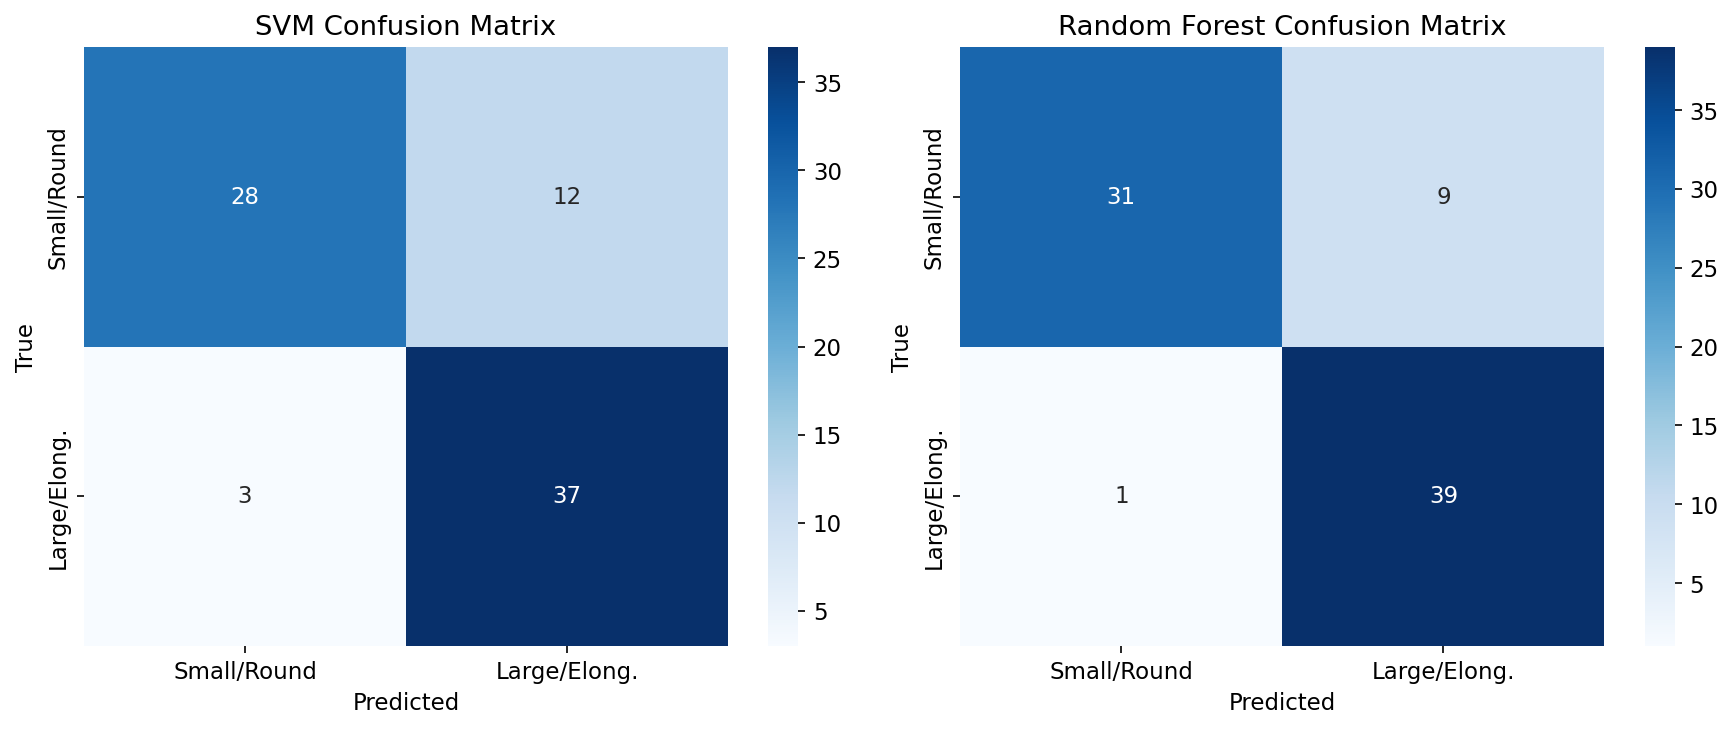

In [7]:
# ==============================================================
# Task 2 — SVM & Random Forest classification
# ==============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, labels_supervised, test_size=0.2, random_state=42,
    stratify=labels_supervised)

t0 = time.time()
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)
svm_runtime = time.time() - t0
y_pred_svm = svm_model.predict(X_test)
print("=== SVM ===")
print(classification_report(y_test, y_pred_svm,
      target_names=['Small/Round', 'Large/Elongated']))

t0 = time.time()
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_runtime = time.time() - t0
y_pred_rf = rf_model.predict(X_test)
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf,
      target_names=['Small/Round', 'Large/Elongated']))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, yp, nm in zip(axes, [y_pred_svm, y_pred_rf], ['SVM', 'Random Forest']):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Small/Round', 'Large/Elong.'],
                yticklabels=['Small/Round', 'Large/Elong.'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{nm} Confusion Matrix')
plt.tight_layout()
plt.savefig('task2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

k=3: Silhouette = 0.1992
k=5: Silhouette = 0.1606
k=7: Silhouette = 0.1788
Best k = 3
PCA explained variance: 47.81%


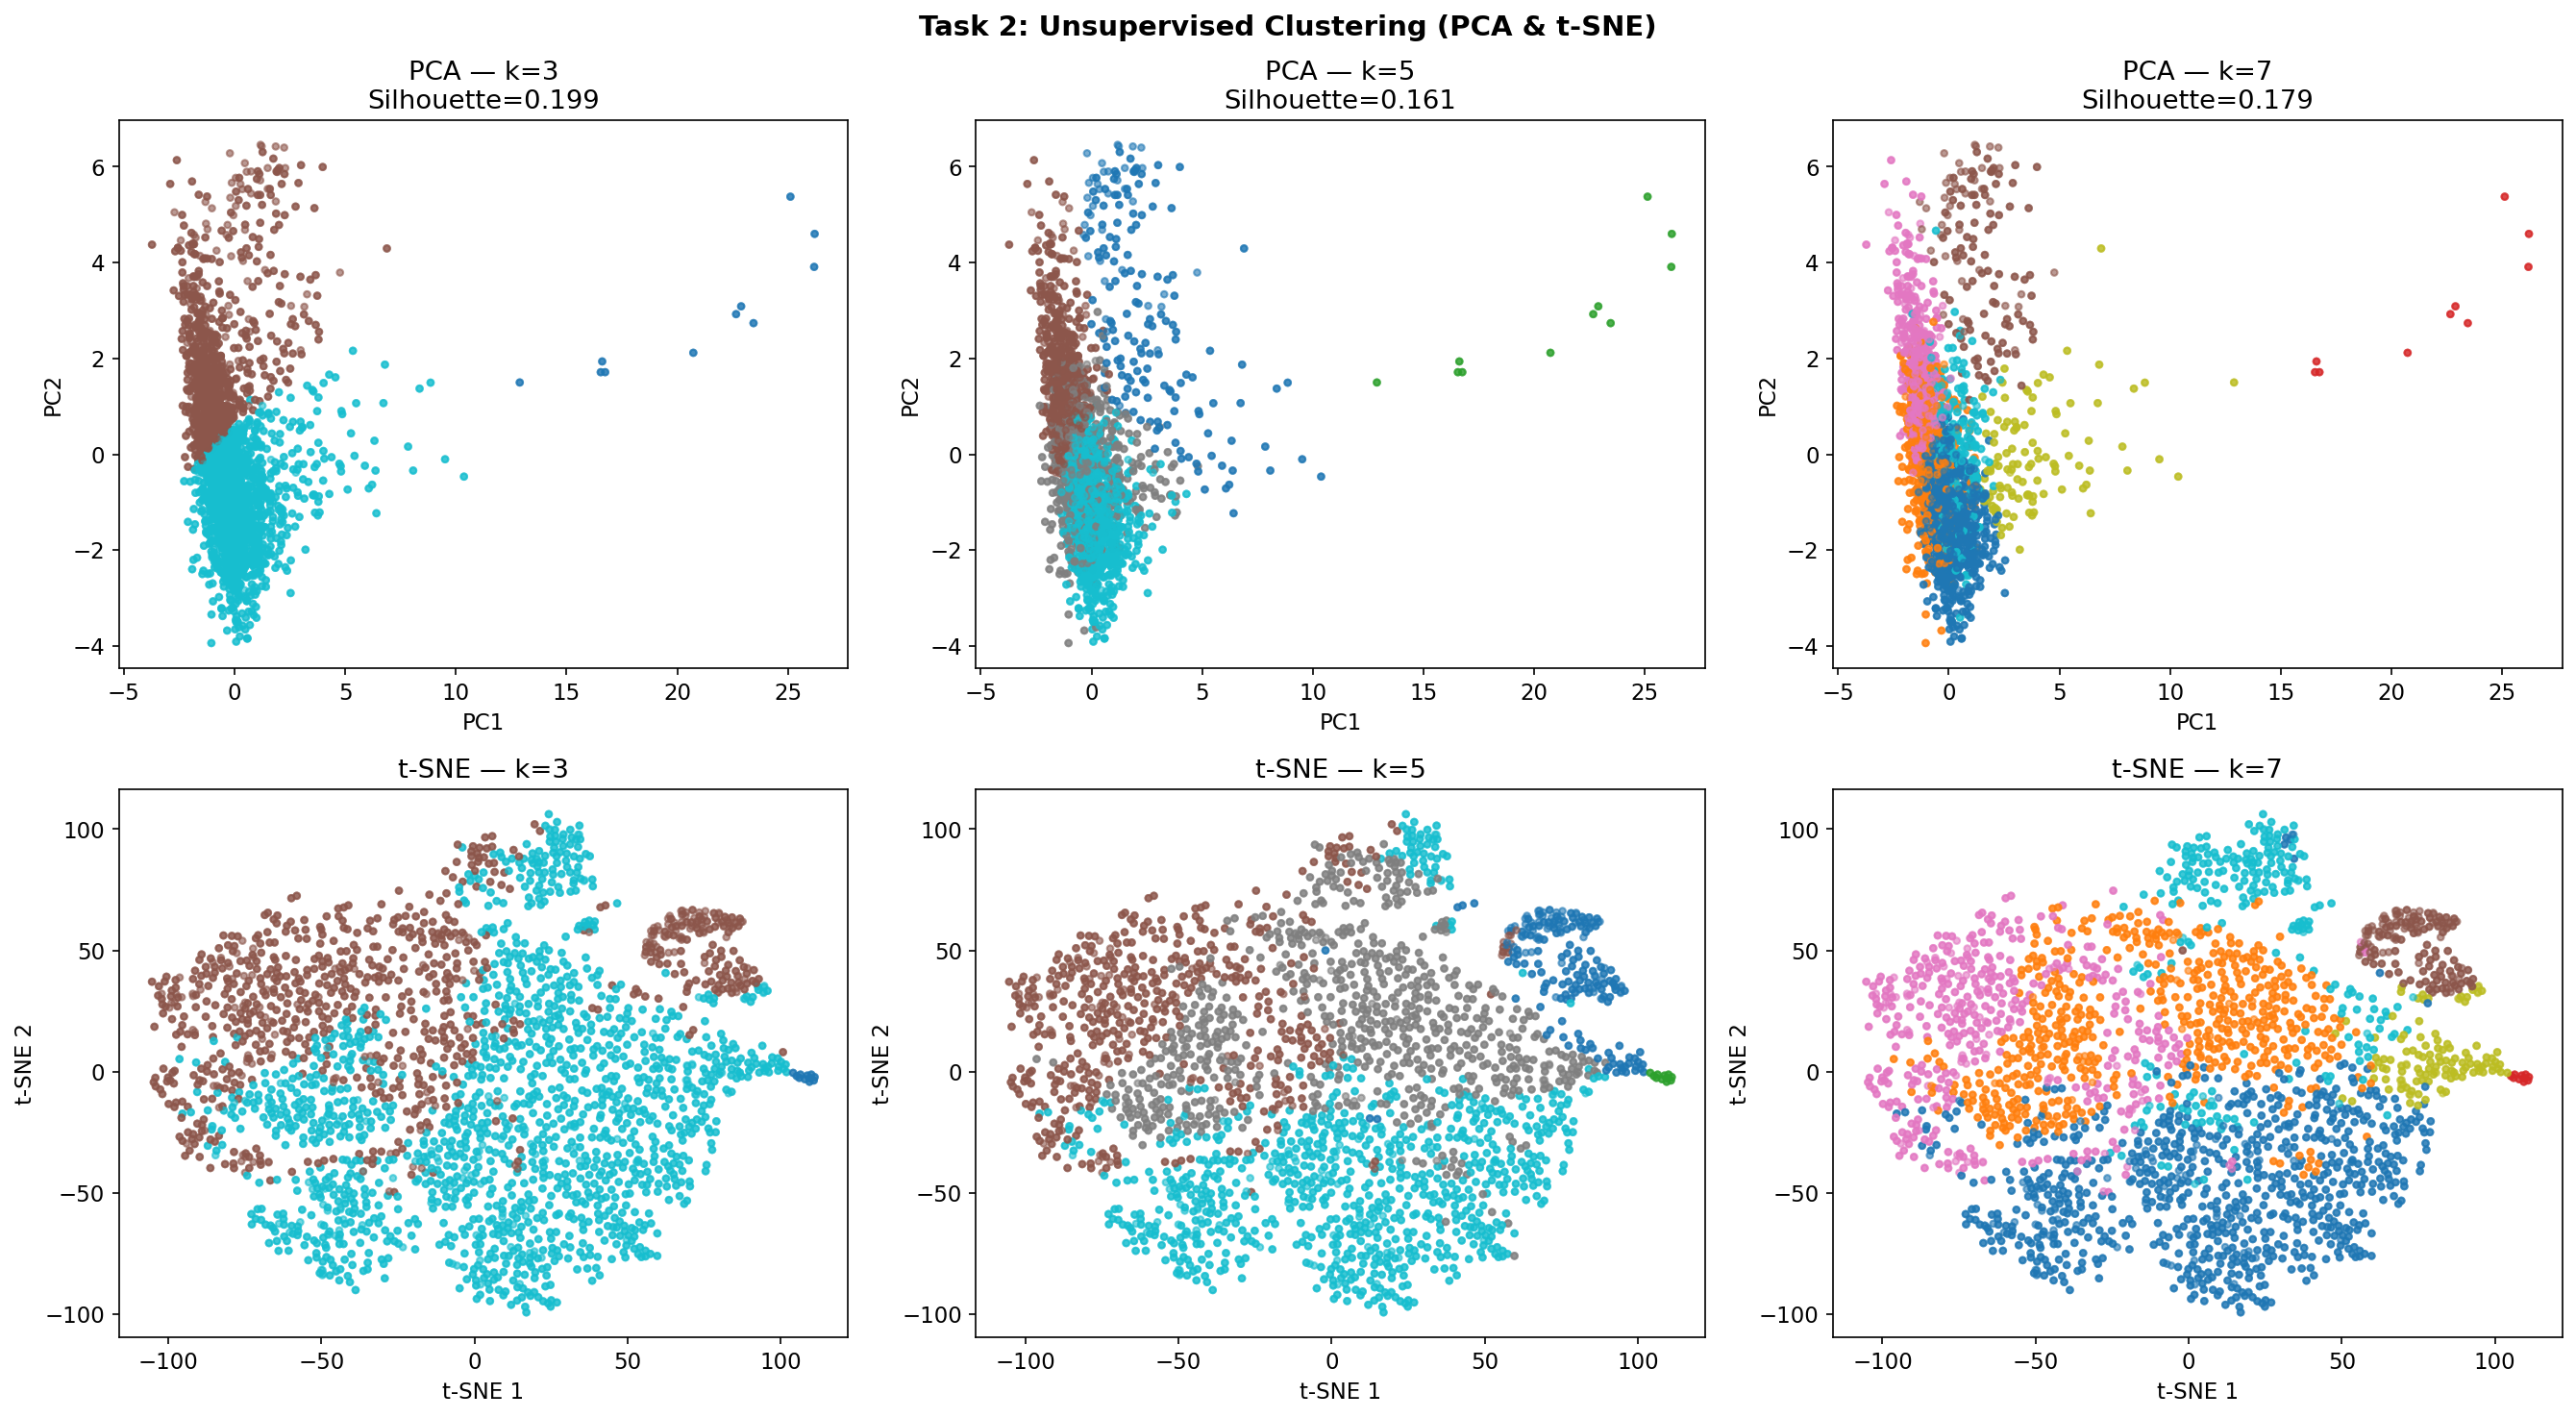

In [8]:
# ==============================================================
# Task 2 — K-Means + PCA / t-SNE (on full feature set)
# ==============================================================
silhouette_scores = {}
cluster_results   = {}
for k in [3, 5, 7]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cl = km.fit_predict(X_scaled)
    sc = silhouette_score(X_scaled, cl)
    silhouette_scores[k] = sc
    cluster_results[k]   = cl
    print(f"k={k}: Silhouette = {sc:.4f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"Best k = {best_k}")

pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

tsne   = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X_scaled)//4))
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for col, k in enumerate([3, 5, 7]):
    axes[0, col].scatter(X_pca[:,0], X_pca[:,1], c=cluster_results[k],
                         cmap='tab10', s=10, alpha=0.6)
    axes[0, col].set_title(f'PCA — k={k}\nSilhouette={silhouette_scores[k]:.3f}')
    axes[0, col].set_xlabel('PC1'); axes[0, col].set_ylabel('PC2')
    axes[1, col].scatter(X_tsne[:,0], X_tsne[:,1], c=cluster_results[k],
                         cmap='tab10', s=10, alpha=0.6)
    axes[1, col].set_title(f't-SNE — k={k}')
    axes[1, col].set_xlabel('t-SNE 1'); axes[1, col].set_ylabel('t-SNE 2')
plt.suptitle('Task 2: Unsupervised Clustering (PCA & t-SNE)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ==============================================================
# Task 2 — Export ml_results.csv (with particle count & classical comparison)
# ==============================================================
# Count particles detected by ML (RF classifier on all labeled data)
rf_all_pred = rf_model.predict(X_labeled[:, top_idx])
ml_particle_count = int(np.sum(rf_all_pred == 1))  # "large/elongated" detections
ml_total_regions  = len(X_labeled)

svm_f1 = round(f1_score(y_test, y_pred_svm, average='weighted'), 4)
rf_f1  = round(f1_score(y_test, y_pred_rf, average='weighted'), 4)

ml_results = pd.DataFrame([
    dict(Method='Classical Watershed', Task='Segmentation',
         Particles_Detected=classical_particle_count,
         F1_Score=np.nan, Precision=np.nan, Recall=np.nan,
         Silhouette_Score=np.nan,
         Runtime_sec=round(classical_runtime / NUM_IMAGES, 3),
         Notes=f'{NUM_IMAGES} images, unsupervised'),
    dict(Method='SVM', Task='Classification',
         Particles_Detected=np.nan,
         F1_Score=svm_f1,
         Precision=round(precision_score(y_test, y_pred_svm, average='weighted'), 4),
         Recall=round(recall_score(y_test, y_pred_svm, average='weighted'), 4),
         Silhouette_Score=np.nan, Runtime_sec=round(svm_runtime, 3),
         Notes=f'{len(sel_idx)} balanced samples, 7 features'),
    dict(Method='Random Forest', Task='Classification',
         Particles_Detected=np.nan,
         F1_Score=rf_f1,
         Precision=round(precision_score(y_test, y_pred_rf, average='weighted'), 4),
         Recall=round(recall_score(y_test, y_pred_rf, average='weighted'), 4),
         Silhouette_Score=np.nan, Runtime_sec=round(rf_runtime, 3),
         Notes=f'{len(sel_idx)} balanced samples, 7 features'),
    dict(Method=f'K-Means (k={best_k})', Task='Clustering',
         Particles_Detected=ml_total_regions,
         F1_Score=np.nan, Precision=np.nan, Recall=np.nan,
         Silhouette_Score=round(silhouette_scores[best_k], 4),
         Runtime_sec=np.nan,
         Notes=f'{ml_total_regions} regions across {ML_NUM} images'),
])
ml_results.to_csv('ml_results.csv', index=False)
print(ml_results.to_string(index=False))
print()
print(f"=== Comparison with Classical Segmentation ===")
print(f"Classical Watershed: {classical_particle_count} particles across {NUM_IMAGES} images")
print(f"ML regions analyzed: {ml_total_regions} across {ML_NUM} images")
print(f"RF classified as large/elongated: {ml_particle_count}/{ml_total_regions} ({ml_particle_count/ml_total_regions:.1%})")
print(f"Runtime: Classical={classical_runtime/NUM_IMAGES:.3f}s/img, SVM={svm_runtime:.3f}s, RF={rf_runtime:.3f}s")
print("\nSaved ml_results.csv")

             Method           Task  Particles_Detected  F1_Score  Precision  Recall  Silhouette_Score  Runtime_sec                            Notes
Classical Watershed   Segmentation              9247.0       NaN        NaN     NaN               NaN        0.316         100 images, unsupervised
                SVM Classification                 NaN    0.8101     0.8292  0.8125               NaN        0.003 400 balanced samples, 7 features
      Random Forest Classification                 NaN    0.8737     0.8906  0.8750               NaN        0.199 400 balanced samples, 7 features
      K-Means (k=3)     Clustering              4292.0       NaN        NaN     NaN            0.1992          NaN    4292 regions across 50 images

=== Comparison with Classical Segmentation ===
Classical Watershed: 9247 particles across 100 images
ML regions analyzed: 4292 across 50 images
RF classified as large/elongated: 3476/4292 (81.0%)
Runtime: Classical=0.316s/img, SVM=0.003s, RF=0.199s

Saved ml_

TensorFlow 2.13.0, GPU: False
Loaded 30 LabelMe-annotated images
Shape: images=(30, 128, 128, 1), masks=(30, 128, 128, 1)
Original split: 24 train, 6 val (no image overlap)
Train images: ['53000X324.png', '25000X36446.png', '53000X1544.png', '25000X4744.png', '11500X40147.png'] ...
Val images:   ['53000X103.png', '11500X200674.png', '25000X12689.png', '25000X27778.png', '25000X65766.png', '11500X194317.png']


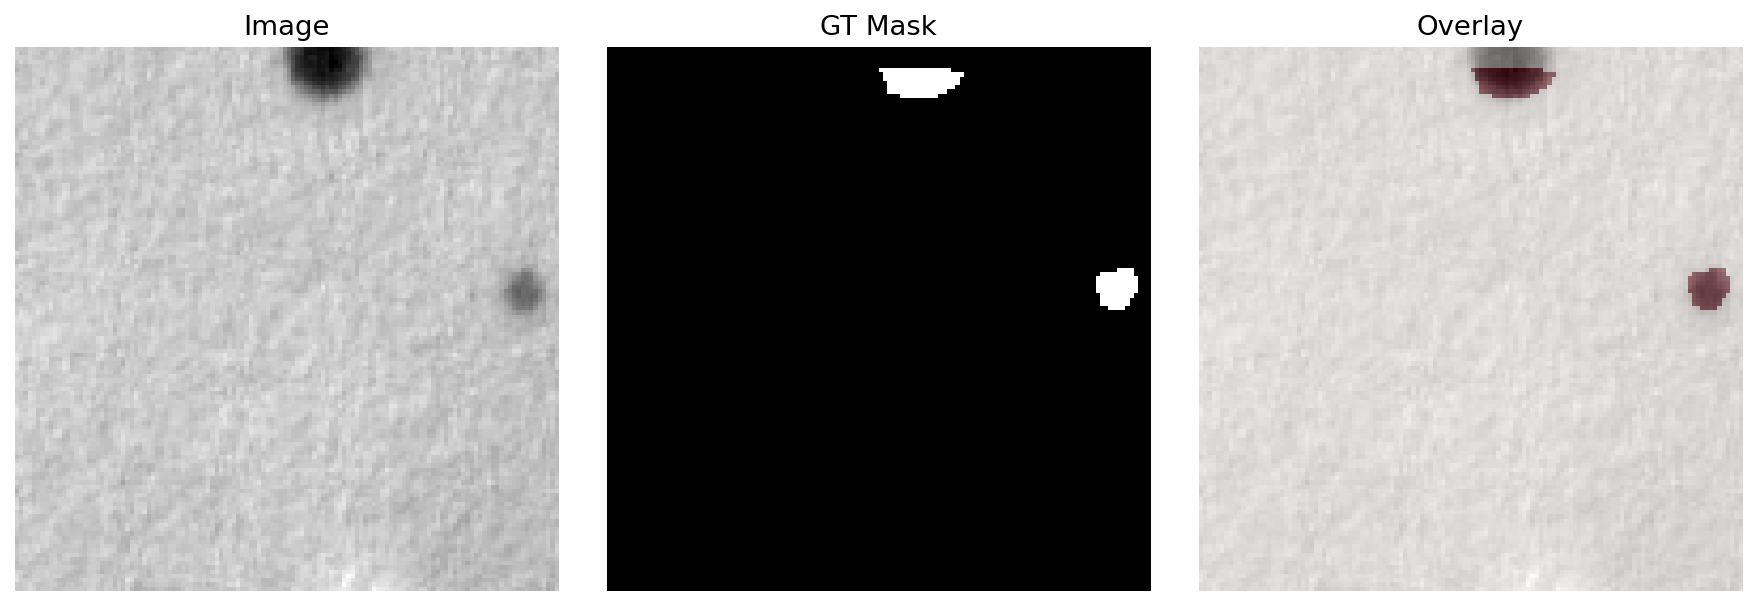

In [10]:
# ==============================================================
# Task 3 — Load LabelMe masks + LEAK-FREE split + augmentation
# ==============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import f1_score as sklearn_f1

print(f"TensorFlow {tf.__version__}, GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")

IMG_SIZE = 128

def load_labelme_data(img_dir, mask_dir, img_size=128):
    images, masks, names = [], [], []
    for img_path in sorted(img_dir.glob('*.png')):
        mask_path = mask_dir / f'{img_path.stem}_mask.png'
        if not mask_path.exists():
            continue
        img = load_gray(img_path)
        msk = imread(str(mask_path))
        if msk.ndim == 3: msk = msk[..., 0]
        msk = (msk > 0).astype(np.float32)
        images.append(sk_resize(img, (img_size, img_size), anti_aliasing=True).astype(np.float32))
        masks.append(sk_resize(msk, (img_size, img_size), order=0,
                               preserve_range=True, anti_aliasing=False).astype(np.float32))
        names.append(img_path.name)
    return np.array(images), np.array(masks), names

if LABELME_IMG_DIR.exists() and LABELME_MASK_DIR.exists():
    X_imgs, Y_masks, dl_names = load_labelme_data(LABELME_IMG_DIR, LABELME_MASK_DIR, IMG_SIZE)
    print(f"Loaded {len(X_imgs)} LabelMe-annotated images")
else:
    raise FileNotFoundError("LabelMe mask directory not found!")

X_imgs  = X_imgs[..., np.newaxis]
Y_masks = Y_masks[..., np.newaxis]
print(f"Shape: images={X_imgs.shape}, masks={Y_masks.shape}")

# --- LEAK-FREE SPLIT: split by ORIGINAL IMAGE first, then augment ---
n_total = len(X_imgs)
n_val   = max(6, n_total // 5)   # ~20% for validation
n_train = n_total - n_val
np.random.seed(42)
indices   = np.random.permutation(n_total)
train_idx = indices[:n_train]
val_idx   = indices[n_train:]

X_train_orig = X_imgs[train_idx]
Y_train_orig = Y_masks[train_idx]
X_val_orig   = X_imgs[val_idx]
Y_val_orig   = Y_masks[val_idx]

print(f"Original split: {n_train} train, {n_val} val (no image overlap)")
print(f"Train images: {[dl_names[i] for i in train_idx[:5]]} ...")
print(f"Val images:   {[dl_names[i] for i in val_idx]}")

# Show sample
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(X_imgs[0,:,:,0], cmap='gray'); axes[0].set_title('Image'); axes[0].axis('off')
axes[1].imshow(Y_masks[0,:,:,0], cmap='gray'); axes[1].set_title('GT Mask'); axes[1].axis('off')
axes[2].imshow(X_imgs[0,:,:,0], cmap='gray')
axes[2].imshow(Y_masks[0,:,:,0], alpha=0.4, cmap='Reds')
axes[2].set_title('Overlay'); axes[2].axis('off')
plt.tight_layout(); plt.show()

In [11]:
# ==============================================================
# Task 3 — Deterministic augmentation (train only, val untouched)
# ==============================================================
def deterministic_augment(images, masks):
    """Generate 5 deterministic augmentation variants + originals = 6x."""
    all_imgs  = [images.copy()]
    all_masks = [masks.copy()]

    # Variant 1: Horizontal flip
    all_imgs.append(np.flip(images, axis=2).copy())
    all_masks.append(np.flip(masks, axis=2).copy())

    # Variant 2: Vertical flip
    all_imgs.append(np.flip(images, axis=1).copy())
    all_masks.append(np.flip(masks, axis=1).copy())

    # Variant 3: 90-degree rotation
    all_imgs.append(np.rot90(images, k=1, axes=(1,2)).copy())
    all_masks.append(np.rot90(masks, k=1, axes=(1,2)).copy())

    # Variant 4: Gaussian noise (image only)
    np.random.seed(42)
    noise = np.random.normal(0, 0.05, images.shape).astype(np.float32)
    all_imgs.append(np.clip(images + noise, 0, 1))
    all_masks.append(masks.copy())

    # Variant 5: Intensity shift (image only)
    np.random.seed(123)
    shifts = np.random.uniform(-0.1, 0.1, (len(images), 1, 1, 1)).astype(np.float32)
    all_imgs.append(np.clip(images + shifts, 0, 1))
    all_masks.append(masks.copy())

    return np.concatenate(all_imgs, axis=0), np.concatenate(all_masks, axis=0)

# Augment ONLY the training set
X_train_dl, Y_train_dl = deterministic_augment(X_train_orig, Y_train_orig)
# Validation stays as-is (no augmentation, no leakage)
X_val_dl  = X_val_orig.copy()
Y_val_dl  = Y_val_orig.copy()

print(f"Train after augmentation: {X_train_dl.shape[0]} ({n_train} originals × 6)")
print(f"Val (untouched originals): {X_val_dl.shape[0]}")
print(f"NO data leakage: train and val come from completely different original images")

Train after augmentation: 144 (24 originals × 6)
Val (untouched originals): 6
NO data leakage: train and val come from completely different original images


Train patches: 534 (from 144 augmented images)
Val patches:   20  (from 6 original val images)
Train labels: class 0=264, class 1=270
Val labels:   class 0=10, class 1=10
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 32)        320       
                                                                 
 batch_normalization (Batch  (None, 48, 48, 32)        128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 24, 24, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 batch_normalizat

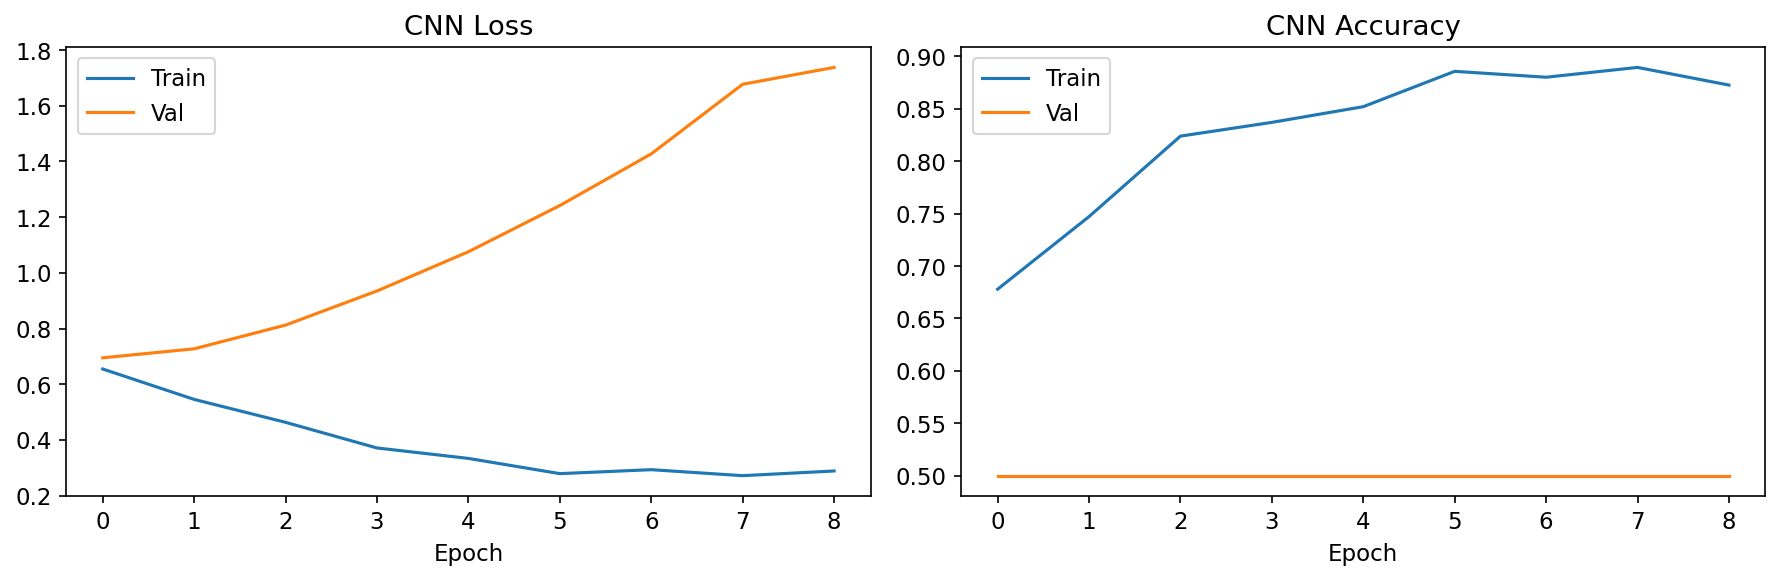

In [12]:
# ==============================================================
# Task 3 — CNN Classification on PARTICLE PATCHES (leak-free)
# ==============================================================
PATCH_SIZE = 48

def extract_particle_patches(images, masks, patch_size=48):
    """Crop particle patches. Label by area: 0=small, 1=large (median split)."""
    patches, areas = [], []
    for img, msk in zip(images, masks):
        img2d = img[:,:,0] if img.ndim == 3 else img
        msk2d = msk[:,:,0] if msk.ndim == 3 else msk
        labeled = ndimage.label(msk2d > 0.5)[0]
        props = measure.regionprops(labeled)
        for p in props:
            if p.area < 15: continue
            cy, cx = int(p.centroid[0]), int(p.centroid[1])
            h = patch_size // 2
            y0, y1 = max(0, cy-h), min(img2d.shape[0], cy+h)
            x0, x1 = max(0, cx-h), min(img2d.shape[1], cx+h)
            patch = img2d[y0:y1, x0:x1]
            if patch.shape[0] < patch_size or patch.shape[1] < patch_size:
                patch = sk_resize(patch, (patch_size, patch_size), anti_aliasing=True)
            patches.append(patch.astype(np.float32))
            areas.append(p.area)
    if len(patches) == 0:
        return np.array([]).reshape(0, patch_size, patch_size, 1), np.array([])
    patches = np.array(patches)[..., np.newaxis]
    areas   = np.array(areas)
    median_a = np.median(areas)
    labels   = (areas >= median_a).astype(int)
    return patches, labels

# Extract patches from TRAIN and VAL SEPARATELY → no leakage
Xp_train, yp_train = extract_particle_patches(X_train_dl, Y_train_dl, PATCH_SIZE)
Xp_val,   yp_val   = extract_particle_patches(X_val_dl,   Y_val_dl,   PATCH_SIZE)
print(f"Train patches: {len(Xp_train)} (from {len(X_train_dl)} augmented images)")
print(f"Val patches:   {len(Xp_val)}  (from {len(X_val_dl)} original val images)")
print(f"Train labels: class 0={np.sum(yp_train==0)}, class 1={np.sum(yp_train==1)}")
print(f"Val labels:   class 0={np.sum(yp_val==0)}, class 1={np.sum(yp_val==1)}")

# Build CNN
cnn_model = keras.Sequential([
    layers.Conv2D(32, 3, activation='relu', padding='same',
                  input_shape=(PATCH_SIZE, PATCH_SIZE, 1)),
    layers.BatchNormalization(), layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(), layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(), layers.MaxPooling2D(2),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])
cnn_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

t0 = time.time()
cnn_history = cnn_model.fit(
    Xp_train, yp_train,
    validation_data=(Xp_val, yp_val),
    epochs=40, batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
               keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-6)],
    verbose=1)
cnn_runtime = time.time() - t0

yp_cnn = (cnn_model.predict(Xp_val) > 0.5).astype(int).flatten()
cnn_f1 = sklearn_f1(yp_val, yp_cnn, average='weighted')
print(f"\nCNN F1={cnn_f1:.4f}, time={cnn_runtime:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cnn_history.history['loss'], label='Train')
axes[0].plot(cnn_history.history['val_loss'], label='Val')
axes[0].set_title('CNN Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(cnn_history.history['accuracy'], label='Train')
axes[1].plot(cnn_history.history['val_accuracy'], label='Val')
axes[1].set_title('CNN Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig('task3_cnn_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Model: "U-Net"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 128, 128, 1)]        0         []                            
                                                                                                  
 conv2d_3 (Conv2D)           (None, 128, 128, 32)         320       ['input_1[0][0]']             
                                                                                                  
 conv2d_4 (Conv2D)           (None, 128, 128, 32)         9248      ['conv2d_3[0][0]']            
                                                                                                  
 batch_normalization_3 (Bat  (None, 128, 128, 32)         128       ['conv2d_4[0][0]']            
 chNormalization)                                                                             

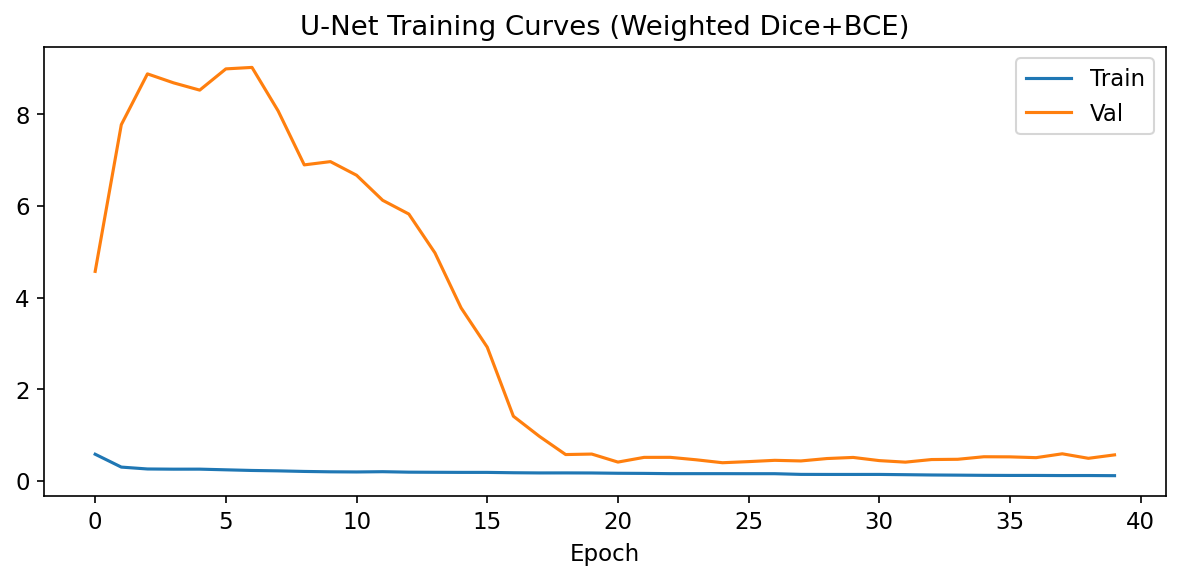

In [13]:
# ==============================================================
# Task 3 — U-Net Segmentation (leak-free split, weighted loss)
# ==============================================================
def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 1)):
    inputs = layers.Input(shape=input_shape)
    # Encoder
    c1 = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
    c1 = layers.Conv2D(32,3,activation='relu',padding='same')(c1)
    c1 = layers.BatchNormalization()(c1)
    p1 = layers.MaxPooling2D(2)(c1); p1 = layers.Dropout(0.25)(p1)

    c2 = layers.Conv2D(64,3,activation='relu',padding='same')(p1)
    c2 = layers.Conv2D(64,3,activation='relu',padding='same')(c2)
    c2 = layers.BatchNormalization()(c2)
    p2 = layers.MaxPooling2D(2)(c2); p2 = layers.Dropout(0.25)(p2)

    c3 = layers.Conv2D(128,3,activation='relu',padding='same')(p2)
    c3 = layers.Conv2D(128,3,activation='relu',padding='same')(c3)
    c3 = layers.BatchNormalization()(c3)
    p3 = layers.MaxPooling2D(2)(c3); p3 = layers.Dropout(0.25)(p3)

    # Bottleneck
    c4 = layers.Conv2D(256,3,activation='relu',padding='same')(p3)
    c4 = layers.Conv2D(256,3,activation='relu',padding='same')(c4)
    c4 = layers.BatchNormalization()(c4)

    # Decoder
    u5 = layers.Concatenate()([layers.UpSampling2D(2)(c4), c3])
    c5 = layers.Conv2D(128,3,activation='relu',padding='same')(u5)
    c5 = layers.Conv2D(128,3,activation='relu',padding='same')(c5)
    c5 = layers.Dropout(0.25)(c5)

    u6 = layers.Concatenate()([layers.UpSampling2D(2)(c5), c2])
    c6 = layers.Conv2D(64,3,activation='relu',padding='same')(u6)
    c6 = layers.Conv2D(64,3,activation='relu',padding='same')(c6)
    c6 = layers.Dropout(0.25)(c6)

    u7 = layers.Concatenate()([layers.UpSampling2D(2)(c6), c1])
    c7 = layers.Conv2D(32,3,activation='relu',padding='same')(u7)
    c7 = layers.Conv2D(32,3,activation='relu',padding='same')(c7)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c7)
    return keras.Model(inputs, outputs, name='U-Net')

def weighted_dice_bce_loss(y_true, y_pred):
    """Combined Dice + weighted BCE loss for imbalanced segmentation."""
    smooth = 1.0
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    dice = 1.0 - (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

    fg_ratio   = tf.reduce_mean(y_true_f)
    pos_weight = tf.clip_by_value(0.5 / (fg_ratio + 1e-7), 1.0, 10.0)
    logits = tf.math.log(y_pred / (1.0 - y_pred + 1e-7) + 1e-7)
    bce = tf.reduce_mean(
        tf.nn.weighted_cross_entropy_with_logits(
            labels=y_true, logits=logits, pos_weight=pos_weight))
    return dice + bce

unet_model = build_unet()
unet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss=weighted_dice_bce_loss,
    metrics=['accuracy'])
unet_model.summary()

t0 = time.time()
unet_history = unet_model.fit(
    X_train_dl, Y_train_dl,
    validation_data=(X_val_dl, Y_val_dl),
    epochs=80, batch_size=4,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=7, min_lr=1e-6)],
    verbose=1)
unet_runtime = time.time() - t0

Y_pred_unet  = unet_model.predict(X_val_dl)
Y_pred_binary = (Y_pred_unet > 0.5).astype(np.float32)

def compute_iou(yt, yp):
    i = np.sum(yt * yp); u = np.sum(yt) + np.sum(yp) - i
    return i / u if u > 0 else 0

def compute_dice(yt, yp):
    i = np.sum(yt * yp); s = np.sum(yt) + np.sum(yp)
    return 2*i / s if s > 0 else 0

iou_scores  = [compute_iou(Y_val_dl[i], Y_pred_binary[i])  for i in range(len(Y_val_dl))]
dice_scores = [compute_dice(Y_val_dl[i], Y_pred_binary[i]) for i in range(len(Y_val_dl))]
mean_iou  = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)
print(f"\nU-Net: IoU={mean_iou:.4f}, Dice={mean_dice:.4f}, time={unet_runtime:.1f}s")
print(f"Per-image IoU: {[f'{s:.3f}' for s in iou_scores]}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(unet_history.history['loss'], label='Train')
ax.plot(unet_history.history['val_loss'], label='Val')
ax.set_title('U-Net Training Curves (Weighted Dice+BCE)')
ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout()
plt.savefig('task3_unet_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

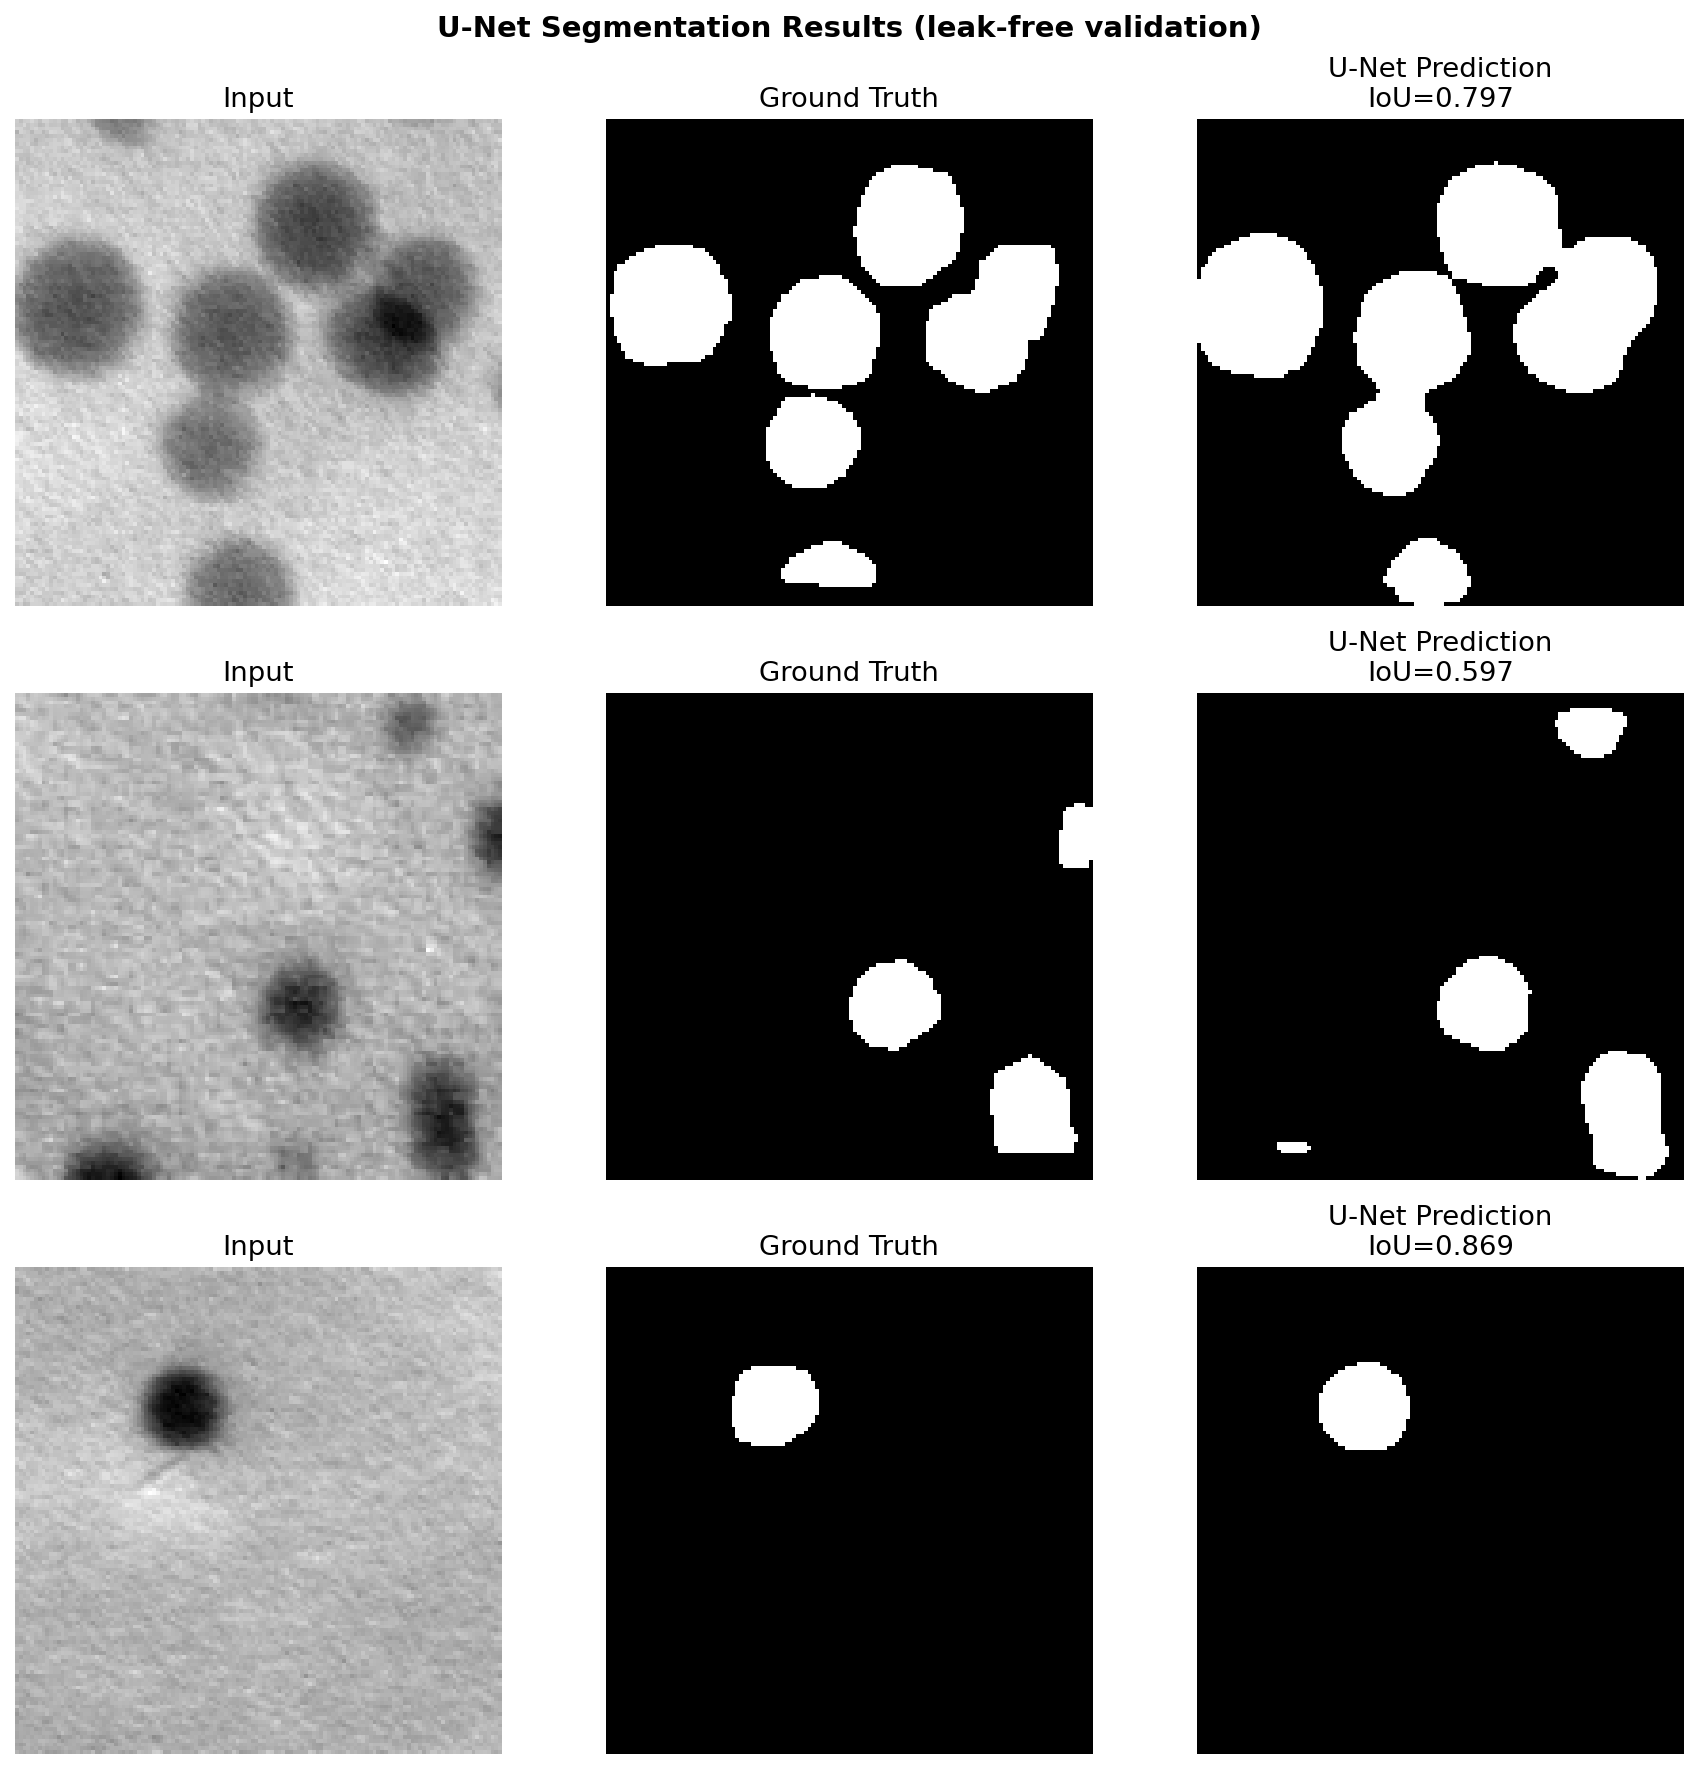

In [14]:
# ==============================================================
# Task 3 — U-Net segmentation visualization
# ==============================================================
n_show = min(3, len(X_val_dl))
fig, axes = plt.subplots(n_show, 3, figsize=(12, 4*n_show))
if n_show == 1: axes = axes[np.newaxis, :]
for i in range(n_show):
    axes[i,0].imshow(X_val_dl[i,:,:,0], cmap='gray')
    axes[i,0].set_title('Input'); axes[i,0].axis('off')
    axes[i,1].imshow(Y_val_dl[i,:,:,0], cmap='gray')
    axes[i,1].set_title('Ground Truth'); axes[i,1].axis('off')
    axes[i,2].imshow(Y_pred_binary[i,:,:,0], cmap='gray')
    axes[i,2].set_title(f'U-Net Prediction\nIoU={iou_scores[i]:.3f}')
    axes[i,2].axis('off')
plt.suptitle('U-Net Segmentation Results (leak-free validation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_unet_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

1/1 [==============================] - 0s 244ms/step


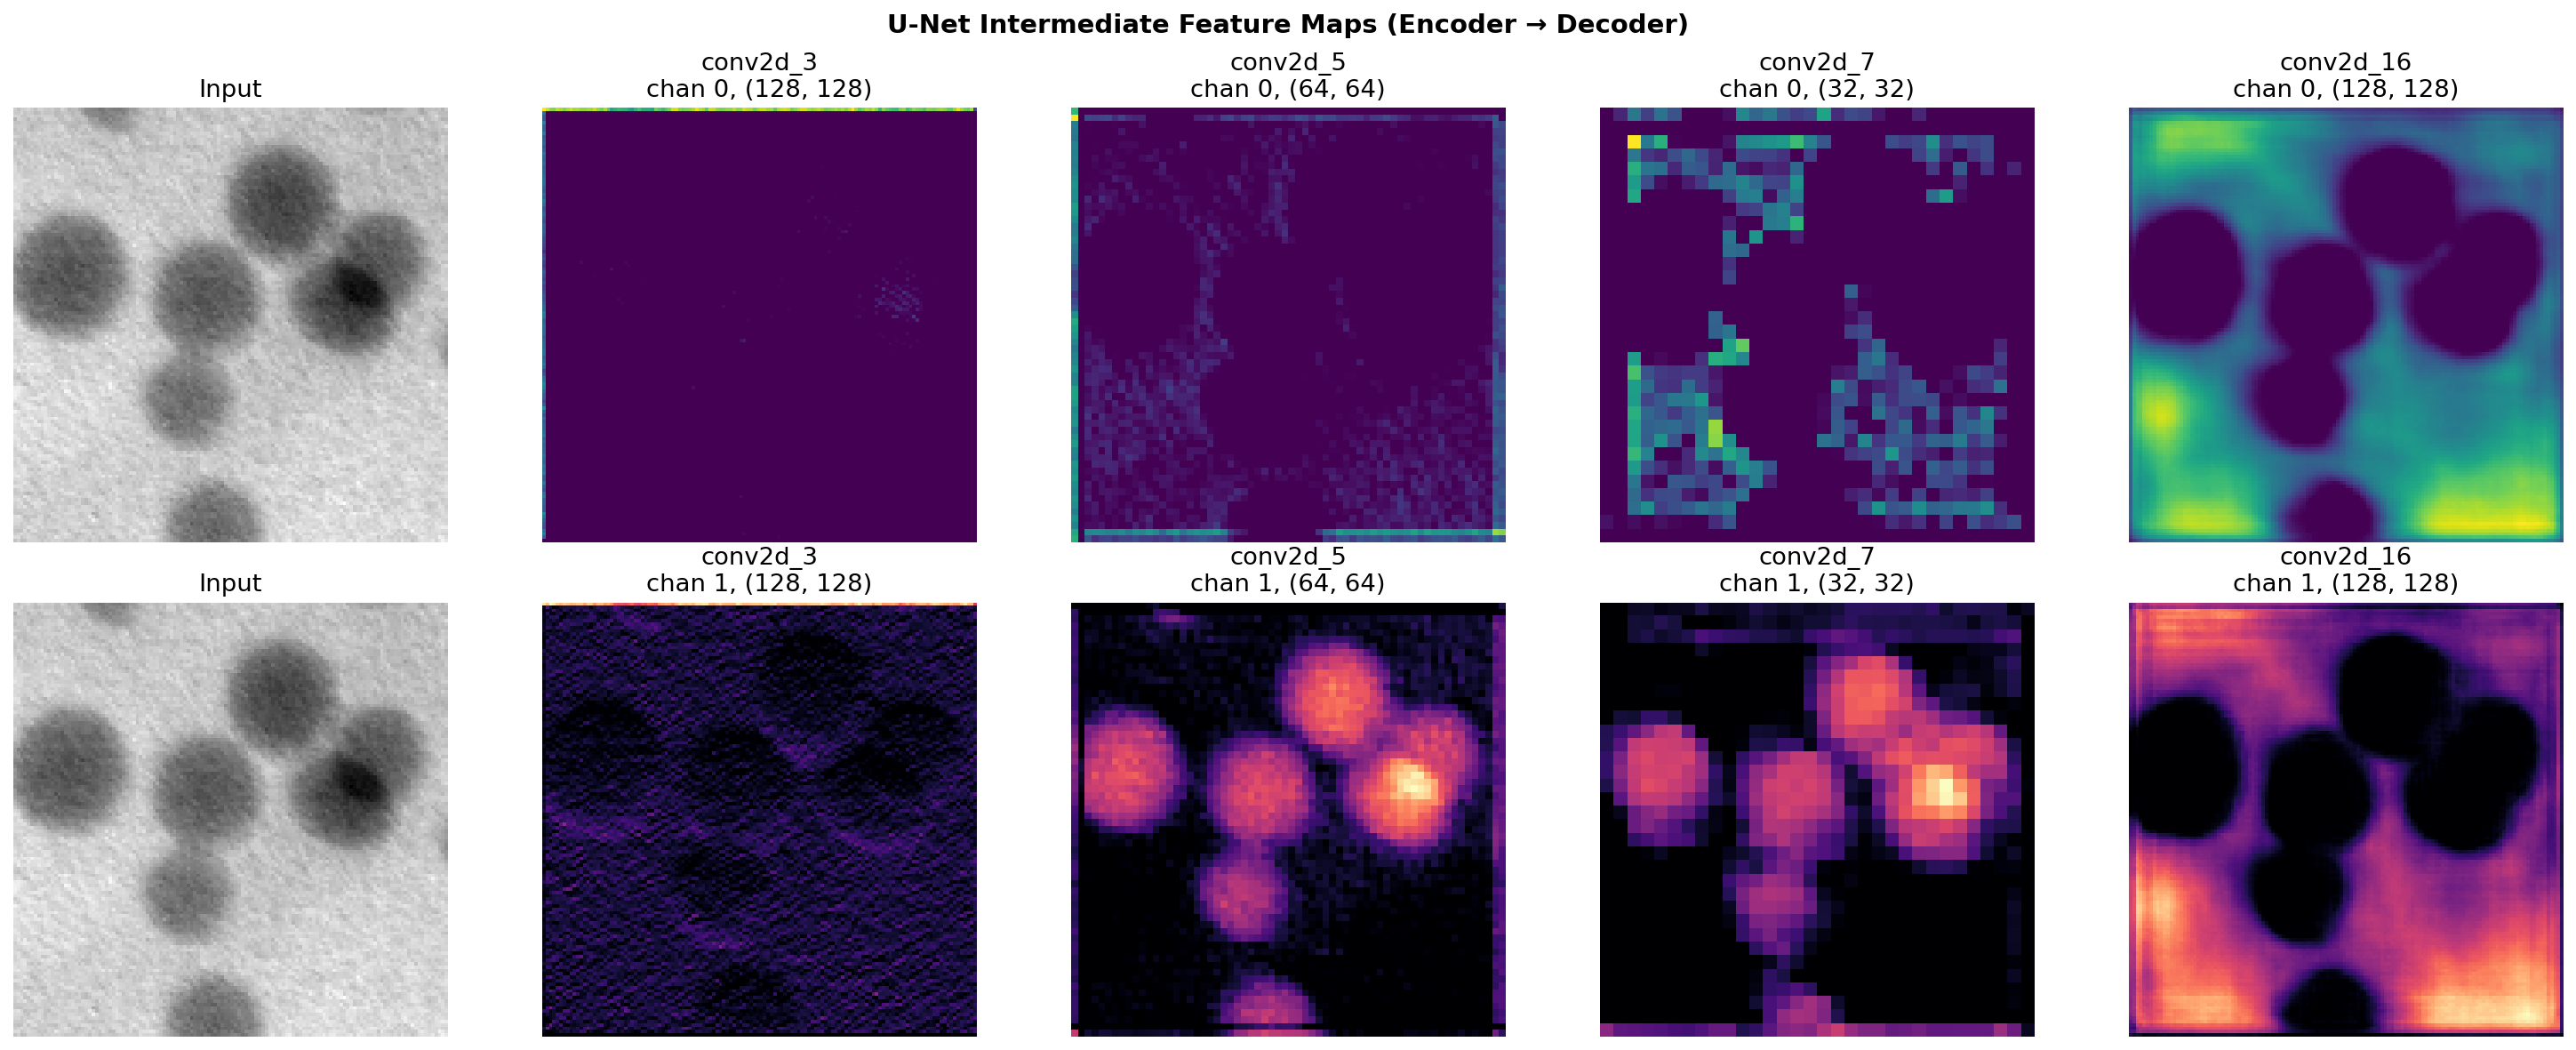

In [15]:
# ==============================================================
# Task 3 — Intermediate feature maps visualization
# ==============================================================
layer_names = [l.name for l in unet_model.layers if 'conv2d' in l.name]
# Select 2 encoder + 2 decoder layers
sel = [layer_names[0], layer_names[2], layer_names[4], layer_names[-2]]
fm_model = keras.Model(inputs=unet_model.input,
                       outputs=[unet_model.get_layer(n).output for n in sel])
fmaps = fm_model.predict(X_val_dl[0:1])

fig, axes = plt.subplots(2, len(sel)+1, figsize=(4*(len(sel)+1), 8))
# Row 0: channel 0 of each layer
axes[0,0].imshow(X_val_dl[0,:,:,0], cmap='gray')
axes[0,0].set_title('Input'); axes[0,0].axis('off')
for j, (fm, nm) in enumerate(zip(fmaps, sel)):
    axes[0,j+1].imshow(fm[0,:,:,0], cmap='viridis')
    axes[0,j+1].set_title(f'{nm}\nchan 0, {fm.shape[1:3]}')
    axes[0,j+1].axis('off')

# Row 1: channel 1 (or mean across channels)
axes[1,0].imshow(X_val_dl[0,:,:,0], cmap='gray')
axes[1,0].set_title('Input'); axes[1,0].axis('off')
for j, (fm, nm) in enumerate(zip(fmaps, sel)):
    ch = min(1, fm.shape[-1]-1)
    axes[1,j+1].imshow(fm[0,:,:,ch], cmap='magma')
    axes[1,j+1].set_title(f'{nm}\nchan {ch}, {fm.shape[1:3]}')
    axes[1,j+1].axis('off')

plt.suptitle('U-Net Intermediate Feature Maps (Encoder → Decoder)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ==============================================================
# Task 3 — Comparison table (all methods)
# ==============================================================
comparison_data = pd.DataFrame({
    'Method': ['Watershed (Classical)', 'SVM', 'Random Forest',
               f'K-Means (k={best_k})', 'CNN (Classification)', 'U-Net (Segmentation)'],
    'Task': ['Segmentation', 'Classification', 'Classification',
             'Clustering', 'Classification', 'Segmentation'],
    'Accuracy_F1_IoU': [
        f'{classical_particle_count} particles',
        f'F1={svm_f1:.3f}',
        f'F1={rf_f1:.3f}',
        f'Silhouette={silhouette_scores[best_k]:.3f}',
        f'F1={cnn_f1:.3f}',
        f'IoU={mean_iou:.3f}, Dice={mean_dice:.3f}'],
    'Runtime': [
        f'{classical_runtime/NUM_IMAGES:.2f}s/img',
        f'{svm_runtime:.3f}s', f'{rf_runtime:.3f}s',
        'Fast (<1s)', f'{cnn_runtime:.1f}s', f'{unet_runtime:.1f}s'],
    'Data_Requirements': [
        'None (unsupervised)',
        '50+ labeled regions',
        '50+ labeled regions',
        'None (unsupervised)',
        'Particle patches + labels',
        '30 pixel-level masks'],
    'Interpretability': [
        'High — direct physical meaning',
        'Medium — feature importance available',
        'Medium — feature importance available',
        'Low — cluster assignment only',
        'Low — black box',
        'Low — black box']
})
comparison_data.to_csv('comparison_table.csv', index=False)
print(comparison_data.to_string(index=False))
print("\nSaved comparison_table.csv")

               Method           Task       Accuracy_F1_IoU    Runtime         Data_Requirements                      Interpretability
Watershed (Classical)   Segmentation        9247 particles  0.32s/img       None (unsupervised)        High — direct physical meaning
                  SVM Classification              F1=0.810     0.003s       50+ labeled regions Medium — feature importance available
        Random Forest Classification              F1=0.874     0.199s       50+ labeled regions Medium — feature importance available
        K-Means (k=3)     Clustering      Silhouette=0.199 Fast (<1s)       None (unsupervised)         Low — cluster assignment only
 CNN (Classification) Classification              F1=0.333       9.2s Particle patches + labels                       Low — black box
 U-Net (Segmentation)   Segmentation IoU=0.758, Dice=0.859     633.1s      30 pixel-level masks                       Low — black box

Saved comparison_table.csv


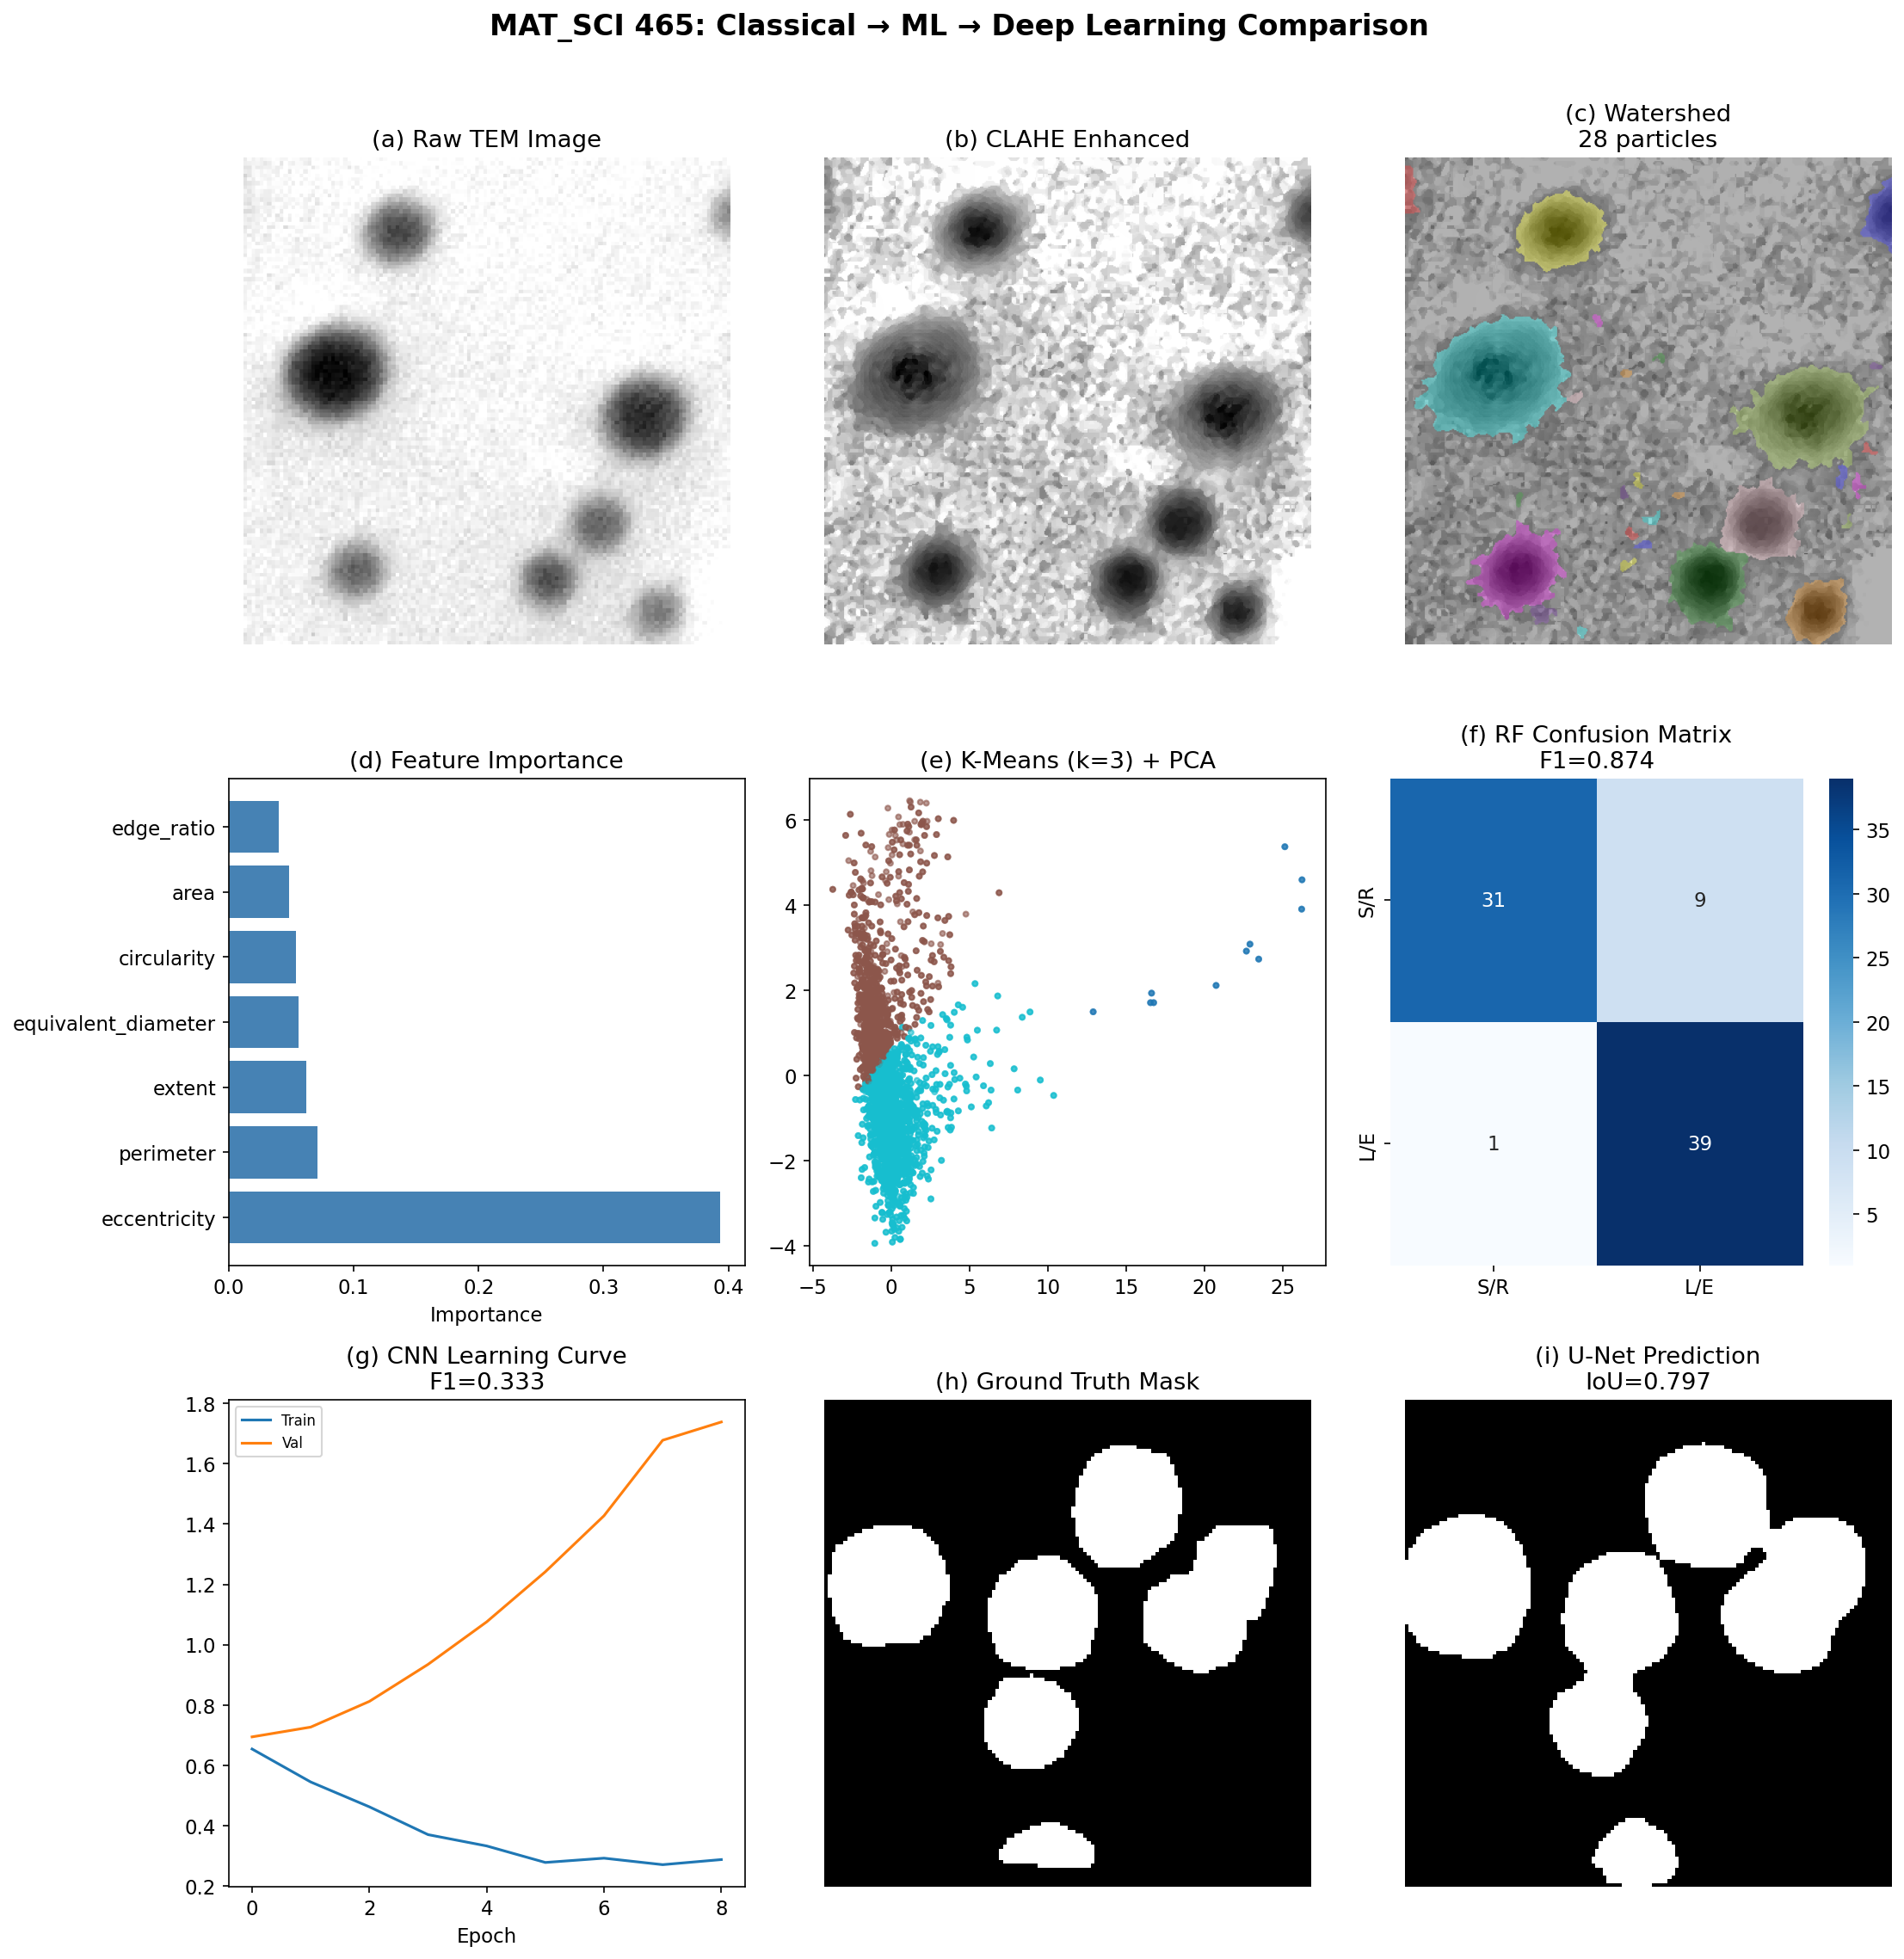

Saved final_3x3_panel.png


In [17]:
# ==============================================================
# Task 3 — Final 3×3 visualization panel
# ==============================================================
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Row 1: Classical
img0 = load_gray(sample_images[0])
_, e0, l0, _ = classical_pipeline(img0)
axes[0,0].imshow(img0, cmap='gray')
axes[0,0].set_title('(a) Raw TEM Image'); axes[0,0].axis('off')
axes[0,1].imshow(e0, cmap='gray')
axes[0,1].set_title('(b) CLAHE Enhanced'); axes[0,1].axis('off')
axes[0,2].imshow(color.label2rgb(l0, image=e0, bg_label=0))
axes[0,2].set_title(f'(c) Watershed\n{l0.max()} particles'); axes[0,2].axis('off')

# Row 2: ML
axes[1,0].barh(importance_df['feature'][:7], importance_df['importance'][:7], color='steelblue')
axes[1,0].set_title('(d) Feature Importance'); axes[1,0].set_xlabel('Importance')

axes[1,1].scatter(X_pca[:,0], X_pca[:,1], c=cluster_results[best_k], cmap='tab10', s=8, alpha=0.6)
axes[1,1].set_title(f'(e) K-Means (k={best_k}) + PCA')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1,2],
            xticklabels=['S/R','L/E'], yticklabels=['S/R','L/E'])
axes[1,2].set_title(f'(f) RF Confusion Matrix\nF1={rf_f1:.3f}')

# Row 3: Deep Learning
axes[2,0].plot(cnn_history.history['loss'], label='Train')
axes[2,0].plot(cnn_history.history['val_loss'], label='Val')
axes[2,0].set_title(f'(g) CNN Learning Curve\nF1={cnn_f1:.3f}')
axes[2,0].set_xlabel('Epoch'); axes[2,0].legend(fontsize=8)

axes[2,1].imshow(Y_val_dl[0,:,:,0], cmap='gray')
axes[2,1].set_title('(h) Ground Truth Mask'); axes[2,1].axis('off')
axes[2,2].imshow(Y_pred_binary[0,:,:,0], cmap='gray')
axes[2,2].set_title(f'(i) U-Net Prediction\nIoU={iou_scores[0]:.3f}'); axes[2,2].axis('off')

plt.suptitle('MAT_SCI 465: Classical → ML → Deep Learning Comparison',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('final_3x3_panel.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved final_3x3_panel.png")